# Hypothesis 6 Justice Principles: Multilingual Descriptive Analysis

This notebook extends the Hypothesis 1 descriptive workflow to Hypothesis 6 experiment runs. We replicate the full descriptive analysis for the three language cohorts (English, Spanish, Mandarin), retaining the University of Bayreuth visual system and comparing outputs across groups.

**Design System Notes**  
- Bayreuth Green `#009260` anchors positive and consensus outcomes.  
- Dark Gray `#48535A`, Medium Gray `#7F8990`, and Light Gray `#EBEBE4` support typography, baselines, and gridlines.  
- Figures target <=12" width, grid-on-y by default, and aligned bar/heatmap annotations.  
- Preference colours map consistently across waves and cohorts for direct comparison.

In [9]:

import json
from dataclasses import dataclass
from collections import OrderedDict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Markdown, display

# ==============================================================================
# UNIVERSITY OF BAYREUTH VISUAL DESIGN SYSTEM
# ==============================================================================

COLORS = {
    "primary_green": "#009260",
    "primary_blue": "#48535A",
    "primary_orange": "#7F8990",
    "accent_1": "#EBEBE4",
    "dark_gray": "#48535A",
    "medium_gray": "#7F8990",
    "light_gray": "#EBEBE4",
    "background": "#FFFFFF",
    "stayed": "#009260",
    "switched": "#48535A",
    "highlight": "#009260",
}

PRINCIPLE_COLORS = {
    "Max Avg Income": COLORS["primary_green"],
    "Max Avg + Floor": COLORS["primary_blue"],
    "Max Avg + Range": COLORS["primary_orange"],
    "Max Floor": COLORS["accent_1"],
}

PRINCIPLE_DISPLAY_NAMES = {
    "Max Avg Income": "Max. Avg. Income",
    "Max Avg + Floor": "Max. Avg. + Floor",
    "Max Avg + Range": "Max. Avg. + Range",
    "Max Floor": "Max. Floor",
    "Failure": "Failure",
    "None": "None",
}

FONT_SIZES = {
    "title": 14,
    "subtitle": 12,
    "axis_label": 11,
    "tick_label": 10,
    "legend": 10,
    "annotation": 9,
}

FONT_FAMILY = "DejaVu Sans"

FIG_SIZES = {
    "single": (9, 5),
    "double": (12, 5),
    "triple": (14, 5),
    "wide_single": (11, 5),
    "tall": (9, 7),
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": COLORS["background"],
    "axes.facecolor": COLORS["background"],
    "axes.edgecolor": COLORS["medium_gray"],
    "axes.linewidth": 1.0,
    "axes.labelsize": FONT_SIZES["axis_label"],
    "axes.titlesize": FONT_SIZES["title"],
    "axes.titleweight": "bold",
    "axes.labelweight": "normal",
    "axes.labelcolor": COLORS["dark_gray"],
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.2,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "grid.color": COLORS["light_gray"],
    "xtick.labelsize": FONT_SIZES["tick_label"],
    "ytick.labelsize": FONT_SIZES["tick_label"],
    "xtick.color": COLORS["dark_gray"],
    "ytick.color": COLORS["dark_gray"],
    "legend.fontsize": FONT_SIZES["legend"],
    "legend.framealpha": 0.95,
    "legend.edgecolor": COLORS["medium_gray"],
    "font.family": "sans-serif",
    "font.sans-serif": [FONT_FAMILY],
    "text.color": COLORS["dark_gray"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette_hex = list(dict.fromkeys([
    COLORS["primary_green"],
    COLORS["primary_blue"],
    COLORS["primary_orange"],
    COLORS["accent_1"],
]))

sns.set_theme(style="whitegrid", context="paper", palette=palette_hex)


In [10]:

LANGUAGE_GROUPS: "OrderedDict[str, str]" = OrderedDict([
    ("English", "english"),
    ("Spanish", "spanish"),
    ("Mandarin", "mandarin"),
])

PRINCIPLE_LABELS = {
    "maximizing_average": "Max Avg Income",
    "maximizing_average_floor_constraint": "Max Avg + Floor",
    "maximizing_average_range_constraint": "Max Avg + Range",
    "maximizing_floor": "Max Floor",
    "failure": "Failure",
    None: "None",
}

CERTAINTY_TO_SCORE = {
    "very_unsure": 1,
    "unsure": 1,
    "neutral": 2,
    "sure": 2,
    "very_sure": 3,
    "no_opinion": np.nan,
    None: np.nan,
}

WAVE_DEFINITIONS = [
    ("initial_ranking", "Wave 1 - Initial", 1),
    ("ranking_2", "Wave 2 - Post-Explanation", 2),
    ("ranking_3", "Wave 3 - Final Phase 1", 3),
]
FINAL_WAVE = ("Wave 4 - Post-Group", 4)
WAVE_ORDER = [label for _, label, _ in WAVE_DEFINITIONS] + [FINAL_WAVE[0]]

PRINCIPLE_ORDER = ["Max Avg + Floor", "Max Avg Income", "Max Avg + Range", "Max Floor"]
PRINCIPLE_DISPLAY_ORDER = [PRINCIPLE_DISPLAY_NAMES[name] for name in PRINCIPLE_ORDER]

RUN_METRIC_COLUMNS = [
    "run_id",
    "consensus_reached",
    "consensus_principle",
    "rounds_to_outcome",
    "max_rounds",
    "total_vote_attempts",
    "successful_votes",
    "total_vote_rounds",
    "group",
]
VOTE_ROUND_COLUMNS = [
    "run_id",
    "round_index",
    "round_number",
    "vote_type",
    "consensus_reached",
    "agreed_principle",
    "agreed_principle_label",
    "agreed_constraint",
    "participant_count",
    "group",
]
RANKING_TOP_COLUMNS = [
    "run_id",
    "agent",
    "wave_label",
    "wave_position",
    "top_principle",
    "top_principle_label",
    "certainty",
    "certainty_score",
    "group",
]
RANKING_LONG_COLUMNS = [
    "run_id",
    "agent",
    "wave_label",
    "wave_position",
    "principle",
    "principle_label",
    "rank",
    "certainty",
    "certainty_score",
    "group",
]


def format_principle_label(name: str) -> str:
    return PRINCIPLE_DISPLAY_NAMES.get(name, name)


def format_principle_labels(labels: List[str]) -> List[str]:
    return [format_principle_label(label) for label in labels]


In [11]:

def locate_project_root(markers: Tuple[str, ...] = ("hypothesis_testing", "config")) -> Path:
    """Locate the project root by walking up the directory tree."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


PROJECT_ROOT = locate_project_root()
RESULTS_ROOT = PROJECT_ROOT / "hypothesis_testing" / "hypothesis_6" / "results"
TERMINAL_ROOT = PROJECT_ROOT / "hypothesis_testing" / "hypothesis_6" / "terminal_outputs"


def _resolve_result_path(path: Path) -> Path:
    if not path.is_absolute():
        path = (PROJECT_ROOT / path).resolve()
    return path


def load_group_runs(language_slug: str, include_logs: bool = True) -> List[Tuple[str, Dict[str, Any]]]:
    result_dir = RESULTS_ROOT / language_slug
    pattern = f"hypothesis_6_{language_slug}_condition_*_config_results.json"
    result_paths = {p.resolve() for p in result_dir.glob(pattern)}

    if include_logs:
        logs_dir = TERMINAL_ROOT / language_slug
        if logs_dir.exists():
            for log_path in logs_dir.glob(f"hypothesis_6_{language_slug}_condition_*_log"):
                try:
                    first_line = log_path.read_text(encoding="utf-8").splitlines()[0]
                except Exception:
                    continue
                parts = first_line.strip().split()
                if parts[:1] == ["CMD:"] and parts[-1].endswith(".json"):
                    candidate = _resolve_result_path(Path(parts[-1]))
                    if candidate.name.startswith(f"hypothesis_6_{language_slug}_condition_"):
                        result_paths.add(candidate)

    runs: List[Tuple[str, Dict[str, Any]]] = []
    for file_path in sorted(result_paths):
        if not file_path.exists():
            print(f"Warning: referenced result missing ({file_path})")
            continue
        with file_path.open("r", encoding="utf-8") as f:
            runs.append((file_path.stem, json.load(f)))

    runs.sort(key=lambda item: item[0])
    return runs


def extract_run_metrics(run_id: str, run_data: Dict[str, Any]) -> Dict[str, Any]:
    general = run_data.get("general_information", {})
    voting = run_data.get("voting_history", {})
    return {
        "run_id": run_id,
        "consensus_reached": general.get("consensus_reached"),
        "consensus_principle": PRINCIPLE_LABELS.get(general.get("consensus_principle"), general.get("consensus_principle")),
        "rounds_to_outcome": general.get("rounds_conducted_phase_2"),
        "max_rounds": general.get("max_rounds_phase_2"),
        "total_vote_attempts": voting.get("total_vote_attempts"),
        "successful_votes": voting.get("successful_votes"),
        "total_vote_rounds": len(voting.get("vote_rounds", [])),
    }


def extract_vote_rounds(run_id: str, run_data: Dict[str, Any]) -> List[Dict[str, Any]]:
    rounds: List[Dict[str, Any]] = []
    for idx, round_info in enumerate(run_data.get("voting_history", {}).get("vote_rounds", []), start=1):
        rounds.append({
            "run_id": run_id,
            "round_index": idx,
            "round_number": round_info.get("round_number"),
            "vote_type": round_info.get("vote_type"),
            "consensus_reached": round_info.get("consensus_reached", False),
            "agreed_principle": round_info.get("agreed_principle"),
            "agreed_principle_label": PRINCIPLE_LABELS.get(round_info.get("agreed_principle"), round_info.get("agreed_principle")),
            "agreed_constraint": round_info.get("agreed_constraint"),
            "participant_count": len(round_info.get("participant_votes", [])),
        })
    return rounds


def _append_ranking_rows(
    *,
    target_top: List[Dict[str, Any]],
    target_long: List[Dict[str, Any]],
    run_id: str,
    agent_name: str,
    wave_label: str,
    wave_pos: int,
    ranking_data: Dict[str, Any],
) -> None:
    """Append ranking information for an agent-wave combination."""
    rankings = ranking_data.get("rankings", [])
    if not rankings:
        return

    certainty = ranking_data.get("certainty")
    certainty_score = CERTAINTY_TO_SCORE.get(certainty, np.nan)
    top_principle = None

    for item in rankings:
        principle_name = item.get("principle")
        rank_value = item.get("rank")
        target_long.append({
            "run_id": run_id,
            "agent": agent_name,
            "wave_label": wave_label,
            "wave_position": wave_pos,
            "principle": principle_name,
            "principle_label": PRINCIPLE_LABELS.get(principle_name, principle_name),
            "rank": rank_value,
            "certainty": certainty,
            "certainty_score": certainty_score,
        })
        if rank_value == 1 and top_principle is None:
            top_principle = principle_name

    if top_principle is not None:
        target_top.append({
            "run_id": run_id,
            "agent": agent_name,
            "wave_label": wave_label,
            "wave_position": wave_pos,
            "top_principle": top_principle,
            "top_principle_label": PRINCIPLE_LABELS.get(top_principle, top_principle),
            "certainty": certainty,
            "certainty_score": certainty_score,
        })


def extract_rankings(run_id: str, run_data: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    top_choice_rows: List[Dict[str, Any]] = []
    long_rows: List[Dict[str, Any]] = []

    for agent in run_data.get("agents", []):
        agent_name = agent.get("name")
        phase1 = agent.get("phase_1", {})
        for key, wave_label, wave_pos in WAVE_DEFINITIONS:
            container = phase1.get(key)
            ranking_data = container.get("ranking_result") if isinstance(container, dict) else None
            if ranking_data:
                _append_ranking_rows(
                    target_top=top_choice_rows,
                    target_long=long_rows,
                    run_id=run_id,
                    agent_name=agent_name,
                    wave_label=wave_label,
                    wave_pos=wave_pos,
                    ranking_data=ranking_data,
                )

        final_ranking = agent.get("phase_2", {}).get("post_group_discussion", {}).get("final_ranking")
        if final_ranking:
            _append_ranking_rows(
                target_top=top_choice_rows,
                target_long=long_rows,
                run_id=run_id,
                agent_name=agent_name,
                wave_label=FINAL_WAVE[0],
                wave_pos=FINAL_WAVE[1],
                ranking_data=final_ranking,
            )

    return top_choice_rows, long_rows


@dataclass
class GroupDataset:
    label: str
    slug: str
    runs: List[Tuple[str, Dict[str, Any]]]
    run_metrics: pd.DataFrame
    vote_rounds: pd.DataFrame
    ranking_top: pd.DataFrame
    ranking_long: pd.DataFrame
    transition_data: Optional[pd.DataFrame] = None
    transition_meta: Optional[Dict[str, int]] = None
    income_df: Optional[pd.DataFrame] = None
    switcher_analysis: Optional[pd.DataFrame] = None


def build_group_dataset(label: str, slug: str, runs: List[Tuple[str, Dict[str, Any]]]) -> GroupDataset:
    run_metrics_records: List[Dict[str, Any]] = []
    vote_round_records: List[Dict[str, Any]] = []
    top_choice_records: List[Dict[str, Any]] = []
    long_ranking_records: List[Dict[str, Any]] = []

    for run_id, run_data in runs:
        run_metrics_records.append(extract_run_metrics(run_id, run_data))
        vote_round_records.extend(extract_vote_rounds(run_id, run_data))
        top_rows, long_rows = extract_rankings(run_id, run_data)
        top_choice_records.extend(top_rows)
        long_ranking_records.extend(long_rows)

    run_metrics = pd.DataFrame(run_metrics_records) if run_metrics_records else pd.DataFrame(columns=RUN_METRIC_COLUMNS[:-1])
    vote_rounds_df = pd.DataFrame(vote_round_records) if vote_round_records else pd.DataFrame(columns=VOTE_ROUND_COLUMNS[:-1])
    ranking_top_df = pd.DataFrame(top_choice_records) if top_choice_records else pd.DataFrame(columns=RANKING_TOP_COLUMNS[:-1])
    ranking_long_df = pd.DataFrame(long_ranking_records) if long_ranking_records else pd.DataFrame(columns=RANKING_LONG_COLUMNS[:-1])

    for df in [run_metrics, vote_rounds_df, ranking_top_df, ranking_long_df]:
        df["group"] = label

    if not ranking_top_df.empty:
        ranking_top_df["wave_label"] = pd.Categorical(ranking_top_df["wave_label"], categories=WAVE_ORDER, ordered=True)
    if not ranking_long_df.empty:
        ranking_long_df["wave_label"] = pd.Categorical(ranking_long_df["wave_label"], categories=WAVE_ORDER, ordered=True)

    return GroupDataset(
        label=label,
        slug=slug,
        runs=runs,
        run_metrics=run_metrics,
        vote_rounds=vote_rounds_df,
        ranking_top=ranking_top_df,
        ranking_long=ranking_long_df,
    )


def build_transition_data(ranking_top_df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, int]]:
    if ranking_top_df.empty:
        cols = ["run_id", "agent"] + [f"wave{i}" for i in range(1, len(WAVE_ORDER) + 1)]
        return pd.DataFrame(columns=cols), {"total_agents": 0, "complete_cases": 0}

    pivot = (
        ranking_top_df
        .sort_values(["run_id", "agent", "wave_position"])
        .pivot_table(index=["run_id", "agent"], columns="wave_position", values="top_principle_label", aggfunc="first")
    )

    for position in range(1, len(WAVE_ORDER) + 1):
        if position not in pivot.columns:
            pivot[position] = np.nan

    pivot = pivot[sorted(pivot.columns)]
    pivot.columns = [f"wave{i}" for i in range(1, len(pivot.columns) + 1)]
    pivot.reset_index(inplace=True)

    required_cols = [f"wave{i}" for i in range(1, len(WAVE_ORDER) + 1)]
    complete = pivot.dropna(subset=required_cols)
    coverage = {
        "total_agents": len(pivot),
        "complete_cases": int(len(complete)),
    }
    return complete, coverage


def extract_income_classes(runs: List[Tuple[str, Dict[str, Any]]], group_label: str) -> pd.DataFrame:
    records: List[Dict[str, Any]] = []
    for run_id, run_data in runs:
        for agent in run_data.get("agents", []):
            post_group = agent.get("phase_2", {}).get("post_group_discussion", {})
            records.append({
                "run_id": run_id,
                "agent": agent.get("name"),
                "income_class_raw": post_group.get("class_put_in"),
                "group": group_label,
            })
    df = pd.DataFrame(records)
    if not df.empty:
        df["income_class"] = df["income_class_raw"].apply(lambda value: standardize_income_class(value))
    return df


def standardize_income_class(raw_class: Optional[str]) -> str:
    if raw_class is None or pd.isna(raw_class):
        return "Unknown"

    class_map = {
        "low": "Low",
        "medium_low": "Medium-Low",
        "medium": "Medium",
        "medium_high": "Medium-High",
        "high": "High",
    }
    return class_map.get(str(raw_class).lower(), "Unknown")


def prepare_switcher_analysis(transition_df: pd.DataFrame, income_df: pd.DataFrame) -> pd.DataFrame:
    if transition_df.empty:
        return pd.DataFrame()

    merged = transition_df.merge(income_df, on=["run_id", "agent"], how="left")
    merged["income_class"] = merged.get("income_class") if "income_class" in merged else merged["income_class_raw"].apply(standardize_income_class)

    wave_cols = [f"wave{i}" for i in range(1, len(WAVE_ORDER) + 1)]
    switch_cols: List[str] = []
    for idx in range(len(wave_cols) - 1):
        col_from = wave_cols[idx]
        col_to = wave_cols[idx + 1]
        col_name = f"switched_{col_from}_{col_to}"
        merged[col_name] = merged[col_from] != merged[col_to]
        switch_cols.append(col_name)

    merged["switched_any"] = merged[switch_cols].any(axis=1)
    merged["num_switches"] = merged[switch_cols].sum(axis=1).astype(int)
    merged["switched_w1_w4"] = merged["wave1"] != merged["wave4"]

    def categorize_switcher(num_switches: int) -> str:
        if num_switches == 0:
            return "Loyal (No switches)"
        if num_switches == 1:
            return "Minor switcher (1 switch)"
        if num_switches == 2:
            return "Moderate switcher (2 switches)"
        return "Major switcher (3+ switches)"

    merged["switcher_category"] = merged["num_switches"].apply(categorize_switcher)
    return merged


In [13]:

def create_preference_ordering_table(ranking_long_df: pd.DataFrame, wave_name: str) -> pd.DataFrame:
    wave_data = ranking_long_df[ranking_long_df["wave_label"] == wave_name].copy()
    if wave_data.empty:
        return pd.DataFrame({"Note": [f"No data available for {wave_name}"]})

    orderings = []
    for (run_id, agent), group in wave_data.groupby(["run_id", "agent"]):
        sorted_group = group.sort_values("rank")
        ordering = tuple(format_principle_labels(sorted_group["principle_label"].tolist()))
        orderings.append({"run_id": run_id, "agent": agent, "ordering": ordering})

    ordering_df = pd.DataFrame(orderings)
    freq_table = ordering_df.groupby("ordering").size().reset_index(name="Count")
    freq_table = freq_table.sort_values("Count", ascending=False).reset_index(drop=True)
    total = freq_table["Count"].sum()
    freq_table["Percentage"] = (freq_table["Count"] / total * 100).round(1)

    def format_ordering(ordering_tuple: Tuple[str, ...]) -> str:
        if len(ordering_tuple) == 4:
            return " > ".join(ordering_tuple)
        return str(ordering_tuple)

    freq_table["Preference Ordering"] = freq_table["ordering"].apply(format_ordering)
    return freq_table[["Preference Ordering", "Count", "Percentage"]]


def summarize_income_preferences(switcher_analysis: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    categories = ["Low", "Medium-Low", "Medium", "Medium-High", "High", "Unknown"]
    summary = []
    for income_class in categories:
        subset = switcher_analysis[switcher_analysis["income_class"] == income_class]
        total = len(subset)
        switched = subset["switched_any"].sum()
        maintained = total - switched
        summary.append({
            "Income Class": income_class,
            "Changed Preference Count": int(switched),
            "Maintained Preference Count": int(maintained),
        })

    summary_df = pd.DataFrame(summary)
    summary_df["Total Agents"] = summary_df["Changed Preference Count"] + summary_df["Maintained Preference Count"]
    summary_df["Changed Preference %"] = np.where(
        summary_df["Total Agents"] > 0,
        (summary_df["Changed Preference Count"] / summary_df["Total Agents"] * 100).round(1),
        0.0,
    )
    summary_df["Maintained Preference %"] = np.where(
        summary_df["Total Agents"] > 0,
        (summary_df["Maintained Preference Count"] / summary_df["Total Agents"] * 100).round(1),
        0.0,
    )

    count_long = summary_df.melt(
        id_vars=["Income Class"],
        value_vars=["Changed Preference Count", "Maintained Preference Count"],
        var_name="Preference Group",
        value_name="Count",
    ).replace({
        "Changed Preference Count": "Changed Preference",
        "Maintained Preference Count": "Maintained Preference",
    })

    percent_long = summary_df.melt(
        id_vars=["Income Class"],
        value_vars=["Changed Preference %", "Maintained Preference %"],
        var_name="Preference Group",
        value_name="Percent",
    ).replace({
        "Changed Preference %": "Changed Preference",
        "Maintained Preference %": "Maintained Preference",
    })

    composition_percent_long = percent_long.merge(
        summary_df[["Income Class", "Total Agents"]],
        on="Income Class",
        how="left"
    )
    return summary_df, count_long, percent_long, composition_percent_long



def plot_income_preference_bars(
    summary_df: pd.DataFrame,
    count_long: pd.DataFrame,
    percent_long: pd.DataFrame,
    title_suffix: str
) -> None:
    if summary_df.empty:
        return

    category_order = summary_df["Income Class"].tolist()
    palette = [COLORS["switched"], COLORS["stayed"]]
    share_long = percent_long.rename(columns={"Percent": "Share"}).copy()
    share_long["Share"] = share_long["Share"].fillna(0)

    fig, axes = plt.subplots(ncols=2, figsize=FIG_SIZES["double"], sharey=True)

    sns.barplot(
        data=count_long,
        x="Count",
        y="Income Class",
        hue="Preference Group",
        order=category_order,
        hue_order=["Changed Preference", "Maintained Preference"],
        orient="h",
        palette=palette,
        ax=axes[0],
    )
    axes[0].set_title("Absolute Counts", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[0].set_xlabel("Number of Agents", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[0].set_ylabel("Income Class", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[0].grid(axis="x", color=COLORS["light_gray"], linewidth=0.6)
    if axes[0].legend_:
        axes[0].legend_.remove()

    sns.barplot(
        data=share_long,
        x="Share",
        y="Income Class",
        hue="Preference Group",
        order=category_order,
        hue_order=["Changed Preference", "Maintained Preference"],
        orient="h",
        palette=palette,
        ax=axes[1],
    )
    axes[1].set_title("Within-Group Share", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[1].set_xlabel("Percentage of Group", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[1].set_ylabel("", fontsize=FONT_SIZES["axis_label"])
    axes[1].grid(axis="x", color=COLORS["light_gray"], linewidth=0.6)
    share_max = share_long["Share"].max() if not share_long.empty else 0
    share_limit = min(100, share_max + 10)
    if share_limit <= 20:
        tick_step = 5
    elif share_limit <= 40:
        tick_step = 10
    else:
        tick_step = 20
    tick_max = share_limit - (share_limit % tick_step) if share_limit >= tick_step else share_limit
    tick_values = np.arange(0, tick_max + tick_step, tick_step)
    axes[1].set_xlim(0, share_limit)
    axes[1].set_xticks(tick_values)
    axes[1].legend(title="Preference Group", framealpha=0.95, edgecolor=COLORS["medium_gray"], loc="lower right")

    for ax in axes:
        ax.spines["left"].set_color(COLORS["medium_gray"])
        ax.spines["bottom"].set_color(COLORS["medium_gray"])
        for patch in ax.patches:
            value = patch.get_width()
            if value <= 0:
                continue
            y = patch.get_y() + patch.get_height() / 2
            if ax is axes[0]:
                label = f"{value:.0f}"
                offset = 0.5
            else:
                label = f"{value:.1f}%"
                offset = 1.0
            ax.text(
                value + offset,
                y,
                label,
                va="center",
                ha="left",
                fontsize=FONT_SIZES["annotation"],
                color=COLORS["dark_gray"],
            )

    fig.suptitle(
        f"Income Distribution by Preference Stability ({title_suffix})",
        fontsize=FONT_SIZES["title"],
        fontweight="bold",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    plt.close(fig)


def plot_income_composition(
    count_long: pd.DataFrame,
    composition_percent_long: pd.DataFrame,
    title_suffix: str
) -> None:
    if count_long.empty:
        return

    palette = [COLORS["switched"], COLORS["stayed"]]
    category_order = list(dict.fromkeys(count_long["Income Class"]))

    fig, axes = plt.subplots(ncols=2, figsize=FIG_SIZES["double"], sharey=True)

    sns.barplot(
        data=count_long,
        x="Count",
        y="Income Class",
        hue="Preference Group",
        order=category_order,
        hue_order=["Changed Preference", "Maintained Preference"],
        orient="h",
        palette=palette,
        ax=axes[0],
    )
    axes[0].set_title("Absolute Counts", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[0].set_xlabel("Number of Agents", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[0].set_ylabel("Income Class", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[0].grid(axis="x", color=COLORS["light_gray"], linewidth=0.6)
    if axes[0].legend_:
        axes[0].legend_.remove()
    axes[0].spines["left"].set_color(COLORS["medium_gray"])
    axes[0].spines["bottom"].set_color(COLORS["medium_gray"])

    legend_handles = [
        Patch(facecolor=COLORS["switched"], edgecolor=COLORS["primary_blue"], label="Changed Pref."),
        Patch(facecolor=COLORS["stayed"], edgecolor=COLORS["primary_blue"], label="Maintained Pref."),
    ]
    axes[0].legend(handles=legend_handles, framealpha=0.95, edgecolor=COLORS["medium_gray"], loc="upper right")

    tuples = count_long[["Income Class", "Preference Group", "Count"]].itertuples(index=False, name=None)
    for patch, (income_class, group, count) in zip(axes[0].patches, tuples):
        if count <= 0:
            continue
        y = patch.get_y() + patch.get_height() / 2
        width = patch.get_width()
        if (group == "Maintained Preference" and count <= 6) or (group == "Changed Preference" and income_class == "Medium-High"):
            x = patch.get_x() + width + 0.8
            ha = "left"
            color = COLORS["dark_gray"]
        else:
            x = patch.get_x() + width / 2
            ha = "center"
            color = COLORS["background"]
        axes[0].text(
            x,
            y,
            f"{int(count)}",
            va="center",
            ha=ha,
            fontsize=FONT_SIZES["annotation"] + 1,
            fontweight="bold",
            color=color,
        )

    percent_frame = composition_percent_long.copy()
    percent_frame["Percent"] = percent_frame["Percent"].fillna(0)

    sns.barplot(
        data=percent_frame,
        x="Percent",
        y="Income Class",
        hue="Preference Group",
        order=category_order,
        hue_order=["Changed Preference", "Maintained Preference"],
        orient="h",
        palette=palette,
        ax=axes[1],
    )
    axes[1].set_title("Relative Counts", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[1].set_xlabel("Share of Income Class (%)", fontsize=FONT_SIZES["axis_label"], labelpad=6)
    axes[1].set_ylabel("")
    axes[1].set_xlim(0, 115)
    axes[1].grid(axis="x", color=COLORS["light_gray"], linewidth=0.6)
    axes[1].spines["left"].set_color(COLORS["medium_gray"])
    axes[1].spines["bottom"].set_color(COLORS["medium_gray"])
    axes[1].spines["top"].set_visible(True)
    axes[1].spines["right"].set_visible(True)
    axes[1].spines["right"].set_color(COLORS["medium_gray"])

    percent_values = percent_frame["Percent"].tolist()
    for patch, percent in zip(axes[1].patches, percent_values):
        if percent <= 0:
            continue
        y = patch.get_y() + patch.get_height() / 2
        if percent >= 30:
            x = patch.get_x() + percent / 2
            ha = "center"
            color = COLORS["background"]
        else:
            x = patch.get_x() + max(percent - 1.2, 0.8)
            ha = "right"
            color = COLORS["background"] if percent >= 12 else COLORS["dark_gray"]
        axes[1].text(
            x,
            y,
            f"{percent:.0f}%",
            va="center",
            ha=ha,
            fontsize=FONT_SIZES["annotation"] + 1,
            fontweight="bold",
            color=color,
        )

    axes[1].legend(handles=legend_handles, framealpha=0.95, edgecolor=COLORS["medium_gray"], loc="upper right")

    fig.suptitle(
        f"Switcher Composition by Income Class ({title_suffix})",
        fontsize=FONT_SIZES["title"],
        fontweight="bold",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    plt.close(fig)


def plot_rounds_to_outcome(run_metrics: pd.DataFrame, title_suffix: str) -> None:
    consensus_rounds = run_metrics[(run_metrics["consensus_reached"] == True) & run_metrics["rounds_to_outcome"].notna()].copy()
    if consensus_rounds.empty:
        print(f"No consensus runs with recorded round counts for {title_suffix}.")
        return

    rounds_int = consensus_rounds["rounds_to_outcome"].astype(int)
    max_observed = int(rounds_int.max())
    round_range = list(range(1, max(max_observed, 10) + 1))
    counts = rounds_int.value_counts().reindex(round_range, fill_value=0)

    fig, ax = plt.subplots(figsize=FIG_SIZES["single"])
    bars = ax.bar(counts.index, counts.values, color=COLORS["primary_green"], edgecolor=COLORS["dark_gray"], alpha=0.85, linewidth=1.2)

    for bar, value in zip(bars, counts.values):
        if value > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{int(value)}", ha="center", va="bottom", fontsize=FONT_SIZES["annotation"], fontweight="bold", color=COLORS["dark_gray"])

    ax.set_xticks(round_range)
    ax.set_xticklabels([str(r) for r in round_range])
    ax.set_xlim(0.5, round_range[-1] + 0.5)
    ax.set_xlabel("Discussion Rounds", fontsize=FONT_SIZES["axis_label"], labelpad=10)
    ax.set_ylabel("Number of Runs", fontsize=FONT_SIZES["axis_label"], labelpad=10)
    ax.set_title(f"Rounds to Consensus Outcome ({title_suffix})", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=10)
    ax.set_ylim(0, counts.max() + 2.5 if counts.max() > 0 else 1)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    rounds_values = rounds_int.values
    print("Consensus Timing Summary:")
    print(f"  Total consensus runs: {len(rounds_values)}")
    print(f"  Range: {rounds_values.min():.0f}-{rounds_values.max():.0f} rounds")
    print(f"  Mean: {rounds_values.mean():.2f} rounds  |  Median: {np.median(rounds_values):.0f} rounds")

def plot_floor_constraint_distribution(vote_rounds: pd.DataFrame, title_suffix: str) -> None:
    parameter_votes = vote_rounds[(vote_rounds["consensus_reached"] == True) & vote_rounds["agreed_constraint"].notna()]
    if parameter_votes.empty:
        print(f"No successful votes with numeric constraints found for {title_suffix}.")
        return

    amounts = parameter_votes["agreed_constraint"].values
    bin_width = 1000
    min_amount = 0
    max_amount = int(np.ceil(amounts.max() / bin_width) * bin_width)
    bins = np.arange(min_amount, max_amount + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=FIG_SIZES["wide_single"])
    counts, bin_edges, _ = ax.hist(amounts, bins=bins, color=COLORS["primary_green"], edgecolor=COLORS["primary_blue"], alpha=0.85, linewidth=1.2)
    for count, edge in zip(counts, bin_edges[:-1]):
        if count > 0:
            ax.text(edge + bin_width / 2, count + 0.4, int(count), ha="center", va="bottom", fontsize=FONT_SIZES["annotation"], fontweight="bold", color=COLORS["dark_gray"])
    ax.set_xticks(bins)
    ax.set_xticklabels([f"${int(b/1000)}k" for b in bins])
    ax.set_xlabel("Floor Constraint Amount", fontsize=FONT_SIZES["axis_label"], labelpad=10)
    ax.set_ylabel("Number of Runs", fontsize=FONT_SIZES["axis_label"], labelpad=10)
    ax.set_title(f"Floor Constraint Distribution ({title_suffix})", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=10)
    ax.set_ylim(0, counts.max() + 2.5)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print("Floor Amount Summary:")
    print(f"  Total votes: {len(amounts)}")
    print(f"  Range: ${amounts.min():,.0f} - ${amounts.max():,.0f}")
    print(f"  Mean: ${amounts.mean():,.0f}  |  Median: ${np.median(amounts):,.0f}  |  SD: ${amounts.std():,.0f}")


def plot_voting_attempts_summary(run_metrics: pd.DataFrame, title_suffix: str) -> None:
    if run_metrics.empty:
        print(f"No voting metrics available for {title_suffix}.")
        return

    metrics = run_metrics.copy()
    metrics["success_rate"] = metrics.apply(
        lambda row: row["successful_votes"] / row["total_vote_attempts"] if row["total_vote_attempts"] not in (None, 0) else np.nan,
        axis=1,
    )

    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZES["double"])
    sns.histplot(metrics["total_vote_attempts"].dropna(), bins=range(0, int(metrics["total_vote_attempts"].max()) + 2), color=COLORS["primary_blue"], edgecolor=COLORS["dark_gray"], ax=axes[0])
    axes[0].set_title(f"Vote Attempts Distribution ({title_suffix})", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[0].set_xlabel("Total Vote Attempts", fontsize=FONT_SIZES["axis_label"])
    axes[0].set_ylabel("Runs", fontsize=FONT_SIZES["axis_label"])

    sns.histplot(metrics["success_rate"].dropna(), bins=np.linspace(0, 1, 11), color=COLORS["primary_green"], edgecolor=COLORS["dark_gray"], ax=axes[1])
    axes[1].set_title(f"Success Rate Distribution ({title_suffix})", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    axes[1].set_xlabel("Success Rate", fontsize=FONT_SIZES["axis_label"])
    axes[1].set_ylabel("Runs", fontsize=FONT_SIZES["axis_label"])
    axes[1].set_xlim(0, 1)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print("Voting Attempts Summary:")
    print(f"  Mean attempts per run: {metrics['total_vote_attempts'].dropna().mean():.2f}")
    print(f"  Median attempts per run: {metrics['total_vote_attempts'].dropna().median():.0f}")
    valid_rates = metrics["success_rate"].dropna()
    if not valid_rates.empty:
        print(f"  Mean success rate: {valid_rates.mean():.2%}")
        print(f"  Median success rate: {valid_rates.median():.2%}")


def plot_preference_stability(transition_df: pd.DataFrame, title_suffix: str) -> None:
    if transition_df.empty:
        print(f"No transition data available for {title_suffix}.")
        return

    transitions = [("wave1", "wave2", "W1→W2"), ("wave2", "wave3", "W2→W3"), ("wave3", "wave4", "W3→W4")]
    stability_stats = []
    for from_col, to_col, label in transitions:
        stayed = (transition_df[from_col] == transition_df[to_col]).sum()
        switched = len(transition_df) - stayed
        stability_stats.append({"Transition": label, "Stayed": stayed, "Switched": switched})

    stats_df = pd.DataFrame(stability_stats)
    stats_long = stats_df.melt(id_vars="Transition", value_vars=["Stayed", "Switched"], var_name="Status", value_name="Count")

    fig, ax = plt.subplots(figsize=FIG_SIZES["single"])
    palette = {"Stayed": COLORS["stayed"], "Switched": COLORS["switched"]}
    sns.barplot(data=stats_long, x="Transition", y="Count", hue="Status", palette=palette, ax=ax)
    ax.set_title(f"Preference Stability Across Waves ({title_suffix})", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=10)
    ax.set_xlabel("Transition", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("Agents", fontsize=FONT_SIZES["axis_label"])
    ax.legend(framealpha=0.95, edgecolor=COLORS["medium_gray"])

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print("Stability Breakdown:")
    for _, row in stats_df.iterrows():
        total = row["Stayed"] + row["Switched"]
        print(f"  {row['Transition']}: {row['Stayed']}/{total} stayed ({row['Stayed']/total*100:.1f}%)")



def plot_transition_heatmaps(transition_df: pd.DataFrame, title_suffix: str) -> None:
    if transition_df.empty:
        return

    fig, axes = plt.subplots(1, 3, figsize=FIG_SIZES["triple"])
    transitions = [
        ("wave1", "wave2", "Wave 1 → 2"),
        ("wave2", "wave3", "Wave 2 → 3"),
        ("wave3", "wave4", "Wave 3 → 4"),
    ]
    stay_stats: List[Tuple[str, int, int]] = []

    for ax, (from_col, to_col, label) in zip(axes, transitions):
        from_series = transition_df[from_col].map(format_principle_label)
        to_series = transition_df[to_col].map(format_principle_label)
        matrix = pd.crosstab(from_series, to_series, margins=False)
        matrix = matrix.reindex(index=PRINCIPLE_DISPLAY_ORDER, columns=PRINCIPLE_DISPLAY_ORDER, fill_value=0)
        row_sums = matrix.sum(axis=1)
        matrix_pct = matrix.div(row_sums.replace(0, np.nan), axis=0) * 100

        sns.heatmap(
            matrix,
            annot=False,
            fmt="d",
            cmap="Blues",
            ax=ax,
            cbar=True,
            linewidths=0.8,
            linecolor=COLORS["light_gray"],
            vmin=0,
            vmax=max(matrix.values.max(), 1),
            cbar_kws={"shrink": 0.8},
        )

        for i, row_label in enumerate(matrix.index):
            for j, col_label in enumerate(matrix.columns):
                count = matrix.iloc[i, j]
                pct = matrix_pct.iloc[i, j]
                text = f"{int(count)}\n({pct:.0f}%)" if count > 0 and not np.isnan(pct) else ""
                weight = "bold" if i == j and count > 0 else "normal"
                color = "white" if count > matrix.values.max() * 0.6 else COLORS["dark_gray"]
                ax.text(
                    j + 0.5,
                    i + 0.5,
                    text,
                    ha="center",
                    va="center",
                    fontsize=FONT_SIZES["annotation"] - 1,
                    fontweight=weight,
                    color=color,
                )

        stay = int(matrix.values.diagonal().sum())
        total = int(matrix.values.sum())
        stay_stats.append((label, stay, total))

        ax.set_title(label, fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
        ax.set_xlabel("To Principle", fontsize=FONT_SIZES["tick_label"])
        ax.set_ylabel("From Principle" if ax == axes[0] else "", fontsize=FONT_SIZES["tick_label"])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=FONT_SIZES["annotation"])
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=FONT_SIZES["annotation"])

    fig.suptitle(
        f"Preference Transition Flows ({title_suffix})",
        fontsize=FONT_SIZES["title"],
        fontweight="bold",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
    plt.close(fig)

    print("Transition Stay Rates:")
    for label, stay, total in stay_stats:
        pct = stay / total * 100 if total > 0 else 0.0
        print(f"  {label}: {stay}/{total} stayed ({pct:.1f}%)")



def plot_long_term_stability(transition_df: pd.DataFrame, title_suffix: str) -> None:
    if transition_df.empty:
        return

    counts = pd.crosstab(transition_df["wave1"], transition_df["wave4"], margins=False)
    counts.index = counts.index.map(format_principle_label)
    counts.columns = counts.columns.map(format_principle_label)
    counts = counts.reindex(index=PRINCIPLE_DISPLAY_ORDER, columns=PRINCIPLE_DISPLAY_ORDER, fill_value=0)
    percent = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZES["double"])

    sns.heatmap(
        counts,
        annot=True,
        fmt="d",
        cmap="Greens",
        ax=axes[0],
        cbar=True,
        linewidths=1.2,
        linecolor="white",
        vmin=0,
        cbar_kws={"shrink": 0.9},
    )
    axes[0].set_title("Counts", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)

    sns.heatmap(
        percent,
        annot=True,
        fmt=".1f",
        cmap="Greens",
        ax=axes[1],
        cbar=True,
        linewidths=1.2,
        linecolor="white",
        vmin=0,
        vmax=100,
        cbar_kws={"shrink": 0.9},
    )
    axes[1].set_title("Percentages", fontsize=FONT_SIZES["subtitle"], fontweight="bold", pad=8)
    for text in axes[1].texts:
        text.set_text(text.get_text() + "%")

    for ax in axes:
        ax.set_xlabel("Final Preference", fontsize=FONT_SIZES["axis_label"], labelpad=8)
        ax.set_ylabel("Initial Preference", fontsize=FONT_SIZES["axis_label"], labelpad=8)
        ax.set_xticklabels(PRINCIPLE_DISPLAY_ORDER, rotation=45, ha="right", fontsize=FONT_SIZES["annotation"])
        ax.set_yticklabels(PRINCIPLE_DISPLAY_ORDER, rotation=0, fontsize=FONT_SIZES["annotation"])

    fig.suptitle(
        f"Long-Term Preference Stability (Wave 1 → Wave 4) ({title_suffix})",
        fontsize=FONT_SIZES["title"],
        fontweight="bold",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    plt.close(fig)

    print(f"Long-Term Stability (Wave 1 → Wave 4) [{title_suffix}]")
    print("=" * 70)
    total_agents = int(counts.values.sum())
    total_loyal = 0
    for principle_name, display_name in zip(PRINCIPLE_ORDER, PRINCIPLE_DISPLAY_ORDER):
        starting_count = counts.loc[display_name].sum()
        loyal_count = counts.loc[display_name, display_name]
        loyalty_rate = percent.loc[display_name, display_name]
        total_loyal += loyal_count
        print(f"{display_name:25s}: {loyal_count:3.0f}/{starting_count:3.0f} maintained ({loyalty_rate:5.1f}%)")
    overall_loyalty = (total_loyal / total_agents) * 100 if total_agents else 0.0
    print(f"{'OVERALL':25s}: {total_loyal:3.0f}/{total_agents:3.0f} agents ({overall_loyalty:5.1f}%)")


def plot_long_term_margin(transition_df: pd.DataFrame, title_suffix: str) -> None:
    if transition_df.empty:
        return

    counts = pd.crosstab(transition_df["wave1"], transition_df["wave4"], margins=False)
    counts.index = counts.index.map(format_principle_label)
    counts.columns = counts.columns.map(format_principle_label)
    counts = counts.reindex(index=PRINCIPLE_DISPLAY_ORDER, columns=PRINCIPLE_DISPLAY_ORDER, fill_value=0)

    row_totals = counts.sum(axis=1)
    col_totals = counts.sum(axis=0)

    fig, ax = plt.subplots(figsize=FIG_SIZES["double"])
    sns.heatmap(
        counts,
        annot=True,
        fmt="d",
        cmap="Greens",
        ax=ax,
        cbar=True,
        linewidths=1.2,
        linecolor="white",
        vmin=0,
        cbar_kws={"shrink": 0.9},
    )
    ax.set_xlabel("Final Preference", fontsize=FONT_SIZES["axis_label"], labelpad=8)
    ax.set_ylabel("Initial Preference", fontsize=FONT_SIZES["axis_label"], labelpad=8)
    ax.set_xticklabels(PRINCIPLE_DISPLAY_ORDER, rotation=45, ha="right", fontsize=FONT_SIZES["annotation"])
    ax.set_yticklabels(PRINCIPLE_DISPLAY_ORDER, rotation=0, fontsize=FONT_SIZES["annotation"])

    num_cols = counts.shape[1]
    for idx, value in enumerate(col_totals):
        ax.text(
            idx + 0.5,
            -0.25,
            f"{int(value)}",
            ha="center",
            va="center",
            fontsize=FONT_SIZES["annotation"] + 1,
            color=COLORS["dark_gray"],
            fontweight="bold",
        )

    for idx, value in enumerate(row_totals):
        ax.text(
            num_cols + 0.1,
            idx + 0.5,
            f"{int(value)}",
            ha="left",
            va="center",
            fontsize=FONT_SIZES["annotation"] + 1,
            color=COLORS["dark_gray"],
            fontweight="bold",
        )

    ax.text(
        num_cols + 0.1,
        -0.25,
        "Σ",
        ha="left",
        va="center",
        fontsize=FONT_SIZES["legend"] + 2,
        color=COLORS["medium_gray"],
        fontweight="bold",
    )

    ax.set_ylim(len(PRINCIPLE_DISPLAY_ORDER), 0)
    ax.set_xlim(0, num_cols + 0.2)

    fig.suptitle(
        f"Long-Term Stability (Counts + Margins) ({title_suffix})",
        fontsize=FONT_SIZES["title"],
        fontweight="bold",
        y=0.98,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    plt.close(fig)



IndentationError: unindent does not match any outer indentation level (<tokenize>, line 500)

In [ ]:

# Load and preprocess each language cohort

group_datasets: "OrderedDict[str, GroupDataset]" = OrderedDict()

for label, slug in LANGUAGE_GROUPS.items():
    runs = load_group_runs(slug)
    dataset = build_group_dataset(label, slug, runs)
    transition_df, coverage = build_transition_data(dataset.ranking_top)
    dataset.transition_data = transition_df
    dataset.transition_meta = coverage

    income_df = extract_income_classes(runs, label)
    dataset.income_df = income_df
    dataset.switcher_analysis = prepare_switcher_analysis(transition_df, income_df)

    group_datasets[label] = dataset
    print(f"Loaded {len(runs)} runs for {label} (transition coverage: {coverage['complete_cases']}/{coverage['total_agents']} agents)")


Loaded 34 runs for English (transition coverage: 170/170 agents)
Loaded 34 runs for Spanish (transition coverage: 170/170 agents)
Loaded 34 runs for Mandarin (transition coverage: 170/170 agents)


In [ ]:

# Cohort-level overview table

overview_records: List[Dict[str, Any]] = []

for label, dataset in group_datasets.items():
    run_metrics = dataset.run_metrics
    consensus_runs = run_metrics[run_metrics["consensus_reached"] == True]
    rounds = consensus_runs["rounds_to_outcome"].dropna()
    overview_records.append({
        "Cohort": label,
        "Runs": run_metrics.shape[0],
        "Consensus Runs": consensus_runs.shape[0],
        "Consensus Rate": consensus_runs.shape[0] / run_metrics.shape[0] if run_metrics.shape[0] else np.nan,
        "Mean Rounds": rounds.mean() if not rounds.empty else np.nan,
        "Median Rounds": rounds.median() if not rounds.empty else np.nan,
    })

overview_df = pd.DataFrame(overview_records)
overview_df["Consensus Rate"] = (overview_df["Consensus Rate"] * 100).round(1)
overview_df["Mean Rounds"] = overview_df["Mean Rounds"].round(2)
overview_df["Median Rounds"] = overview_df["Median Rounds"].round(1)

display(Markdown("### High-Level Cohort Overview"))
display(overview_df)


### High-Level Cohort Overview

,Cohort,Runs,Consensus Runs,Consensus Rate,Mean Rounds,Median Rounds
0,English,34,30,88.2,5.87,4.5
1,Spanish,34,19,55.9,6.00,5.0
2,Mandarin,34,28,82.4,5.36,4.0


## English Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,30
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,83,48.8
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,41,24.1
2,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,12,7.1
3,Max. Avg. + Floor > Max. Avg. Income > Max. Fl...,10,5.9
4,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,5,2.9
5,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,5,2.9
6,Max. Avg. + Range > Max. Avg. + Floor > Max. F...,3,1.8
7,Max. Avg. Income > Max. Avg. + Floor > Max. Av...,3,1.8
8,Max. Avg. Income > Max. Avg. + Floor > Max. Fl...,3,1.8
9,Max. Floor > Max. Avg. + Floor > Max. Avg. + R...,3,1.8


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,69,40.6
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,43,25.3
2,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,14,8.2
3,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,14,8.2
4,Max. Avg. + Floor > Max. Avg. Income > Max. Fl...,12,7.1
5,Max. Floor > Max. Avg. + Floor > Max. Avg. + R...,8,4.7
6,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,3,1.8
7,Max. Avg. + Range > Max. Floor > Max. Avg. + F...,2,1.2
8,Max. Avg. Income > Max. Avg. + Floor > Max. Av...,2,1.2
9,Max. Avg. + Range > Max. Floor > Max. Avg. Inc...,1,0.6


### Rounds to Outcome

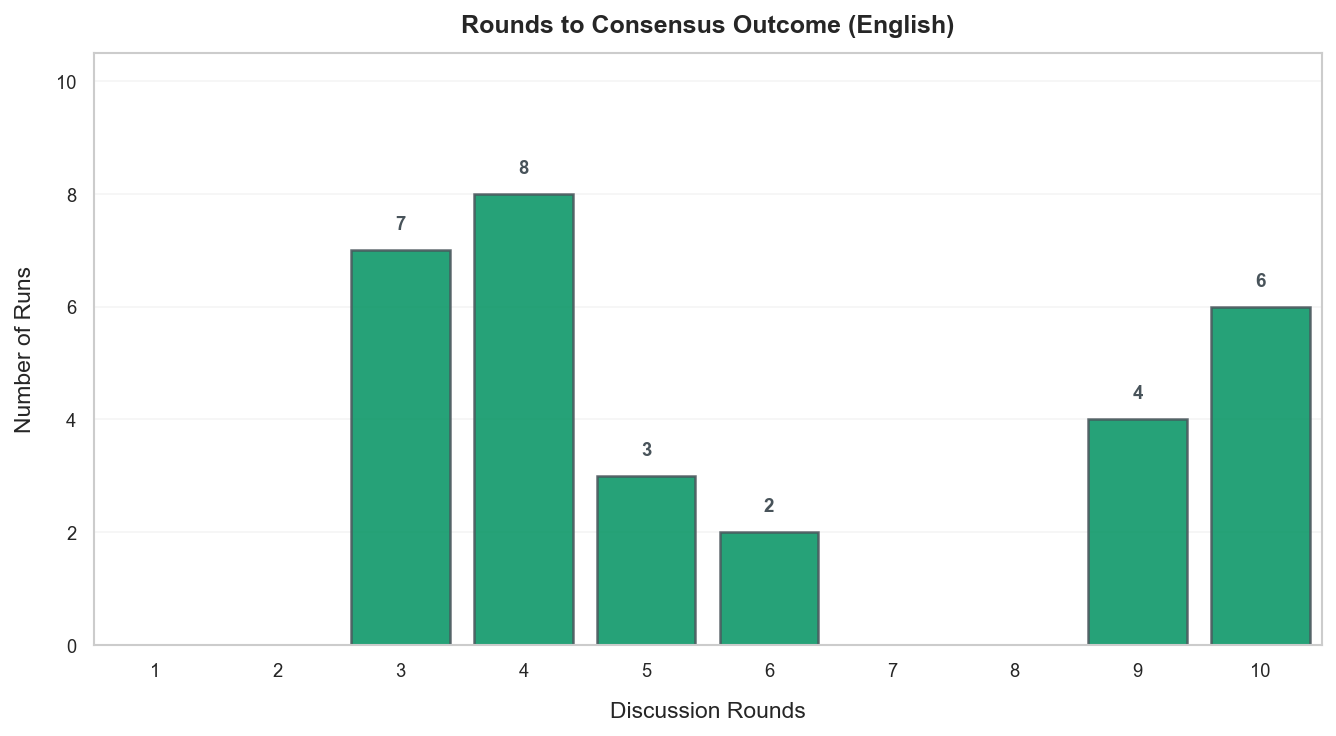

Consensus Timing Summary:
  Total consensus runs: 30
  Range: 3-10 rounds
  Mean: 5.87 rounds  |  Median: 4 rounds


### Floor Constraint Amounts

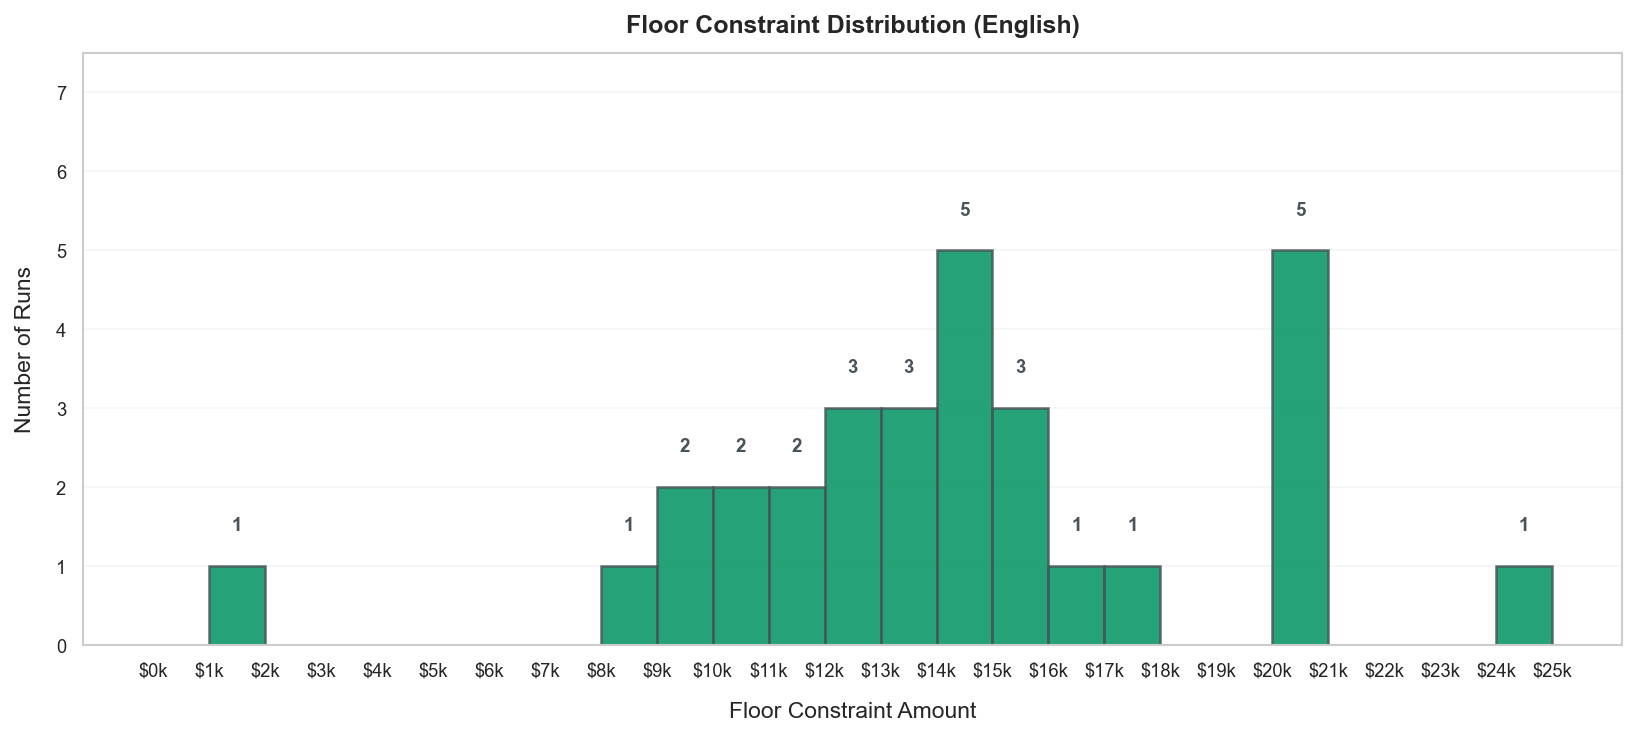

Floor Amount Summary:
  Total votes: 30
  Range: $1,000 - $25,000
  Mean: $14,017  |  Median: $14,000  |  SD: $4,574


### Voting Attempts and Success Rate

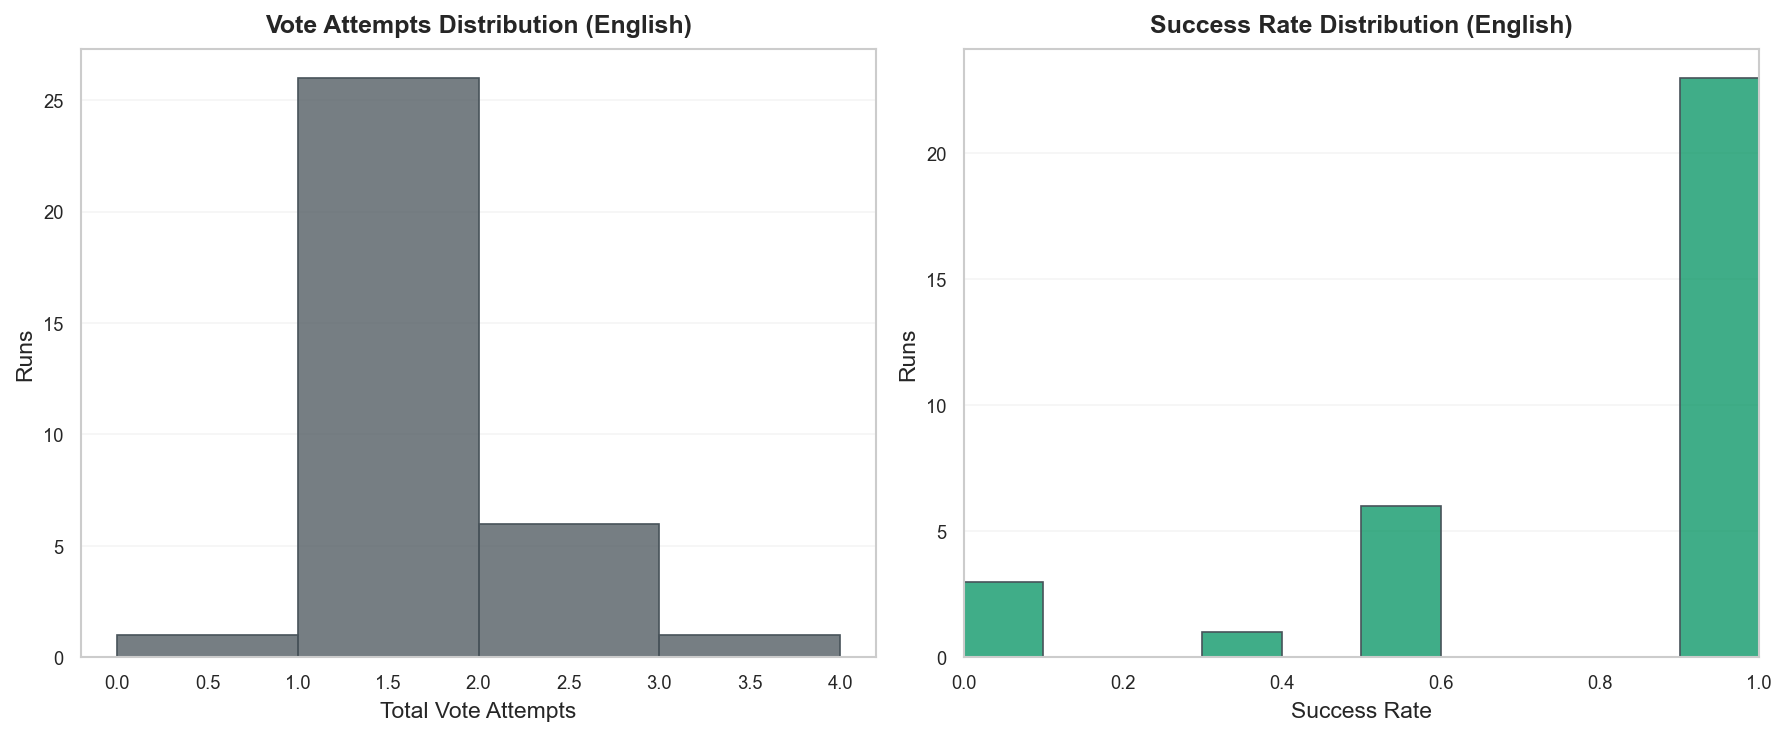

Voting Attempts Summary:
  Mean attempts per run: 1.21
  Median attempts per run: 1
  Mean success rate: 79.80%
  Median success rate: 100.00%


### Preference Evolution and Transitions

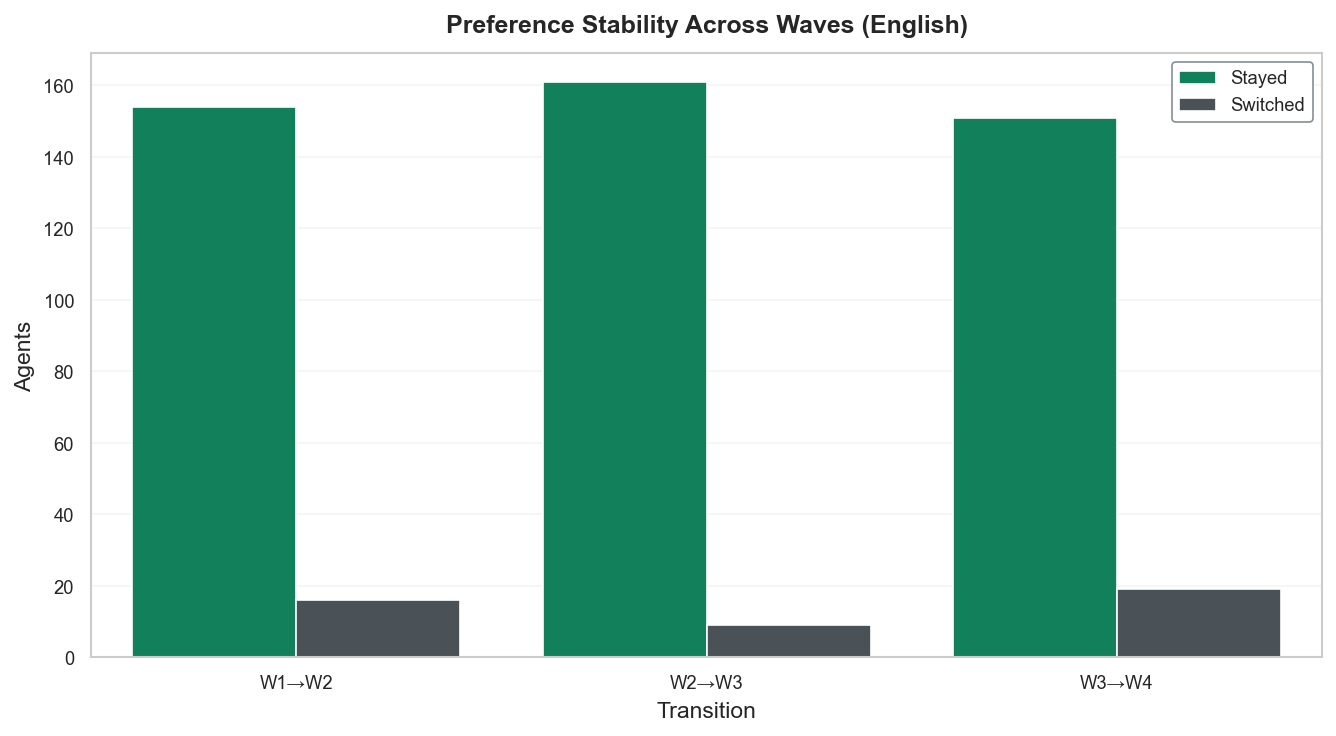

Stability Breakdown:
  W1→W2: 154/170 stayed (90.6%)
  W2→W3: 161/170 stayed (94.7%)
  W3→W4: 151/170 stayed (88.8%)


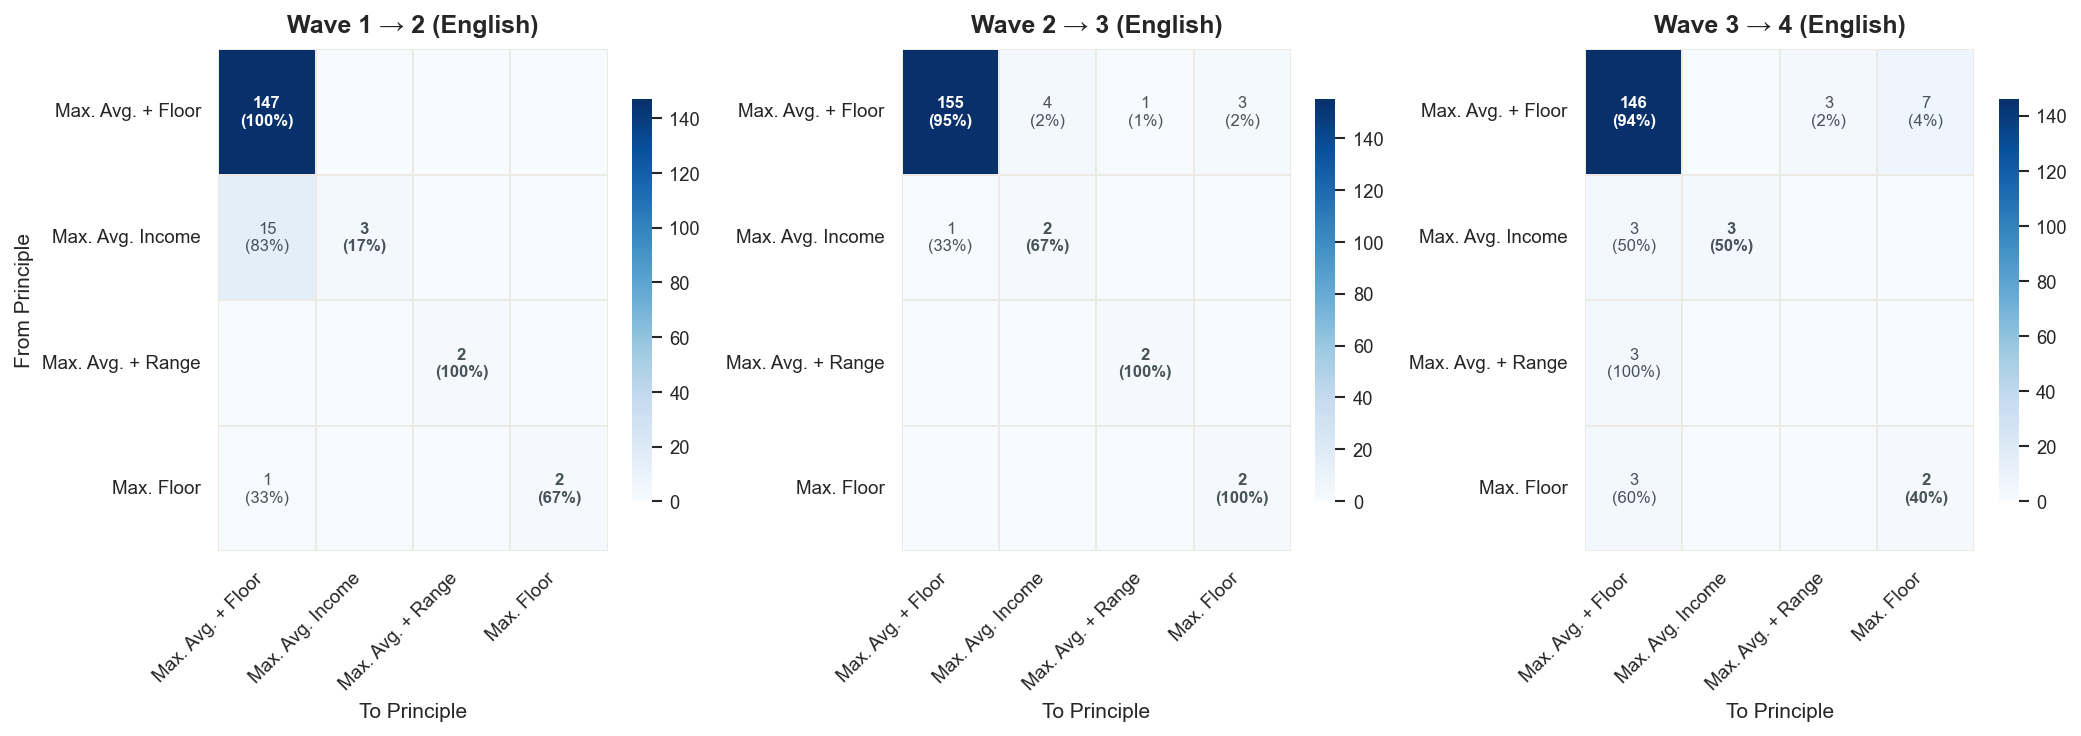

Transition Stay Rates:
  Wave 1 → 2: 154/170 stayed (90.6%)
  Wave 2 → 3: 161/170 stayed (94.7%)
  Wave 3 → 4: 151/170 stayed (88.8%)


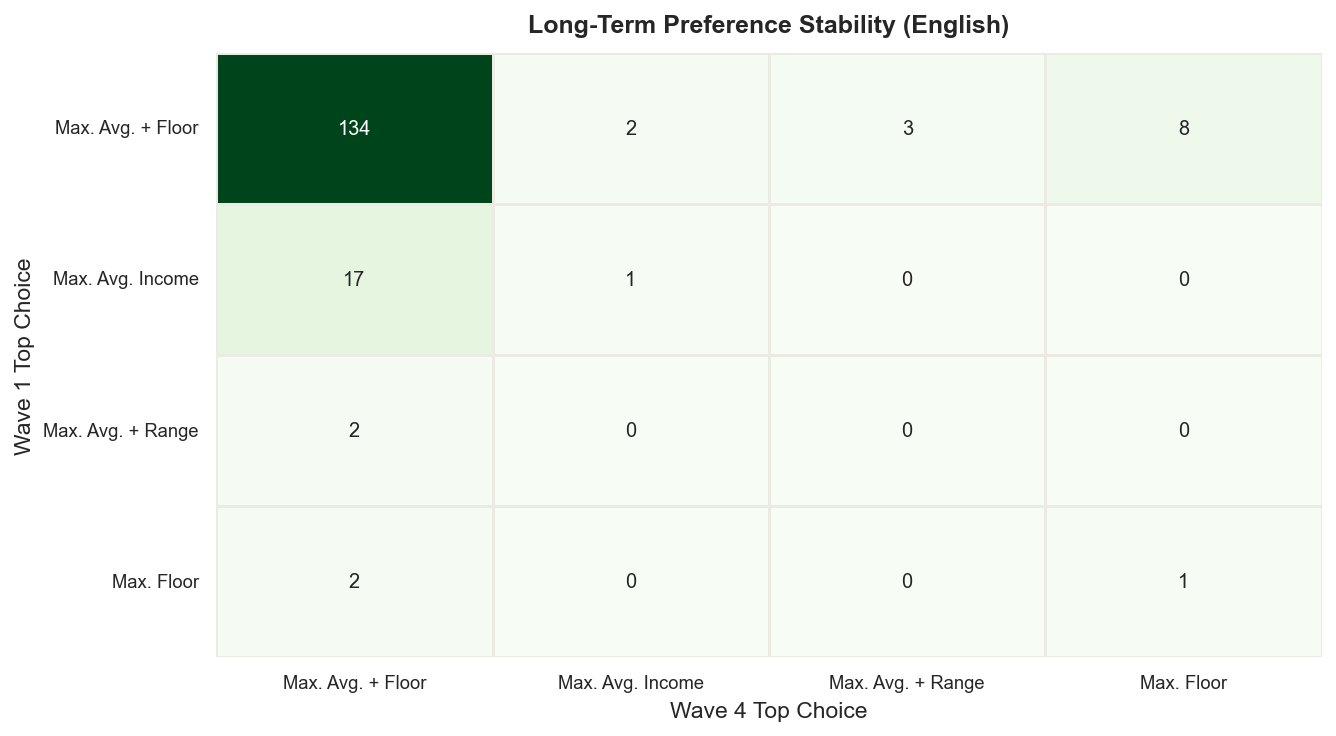

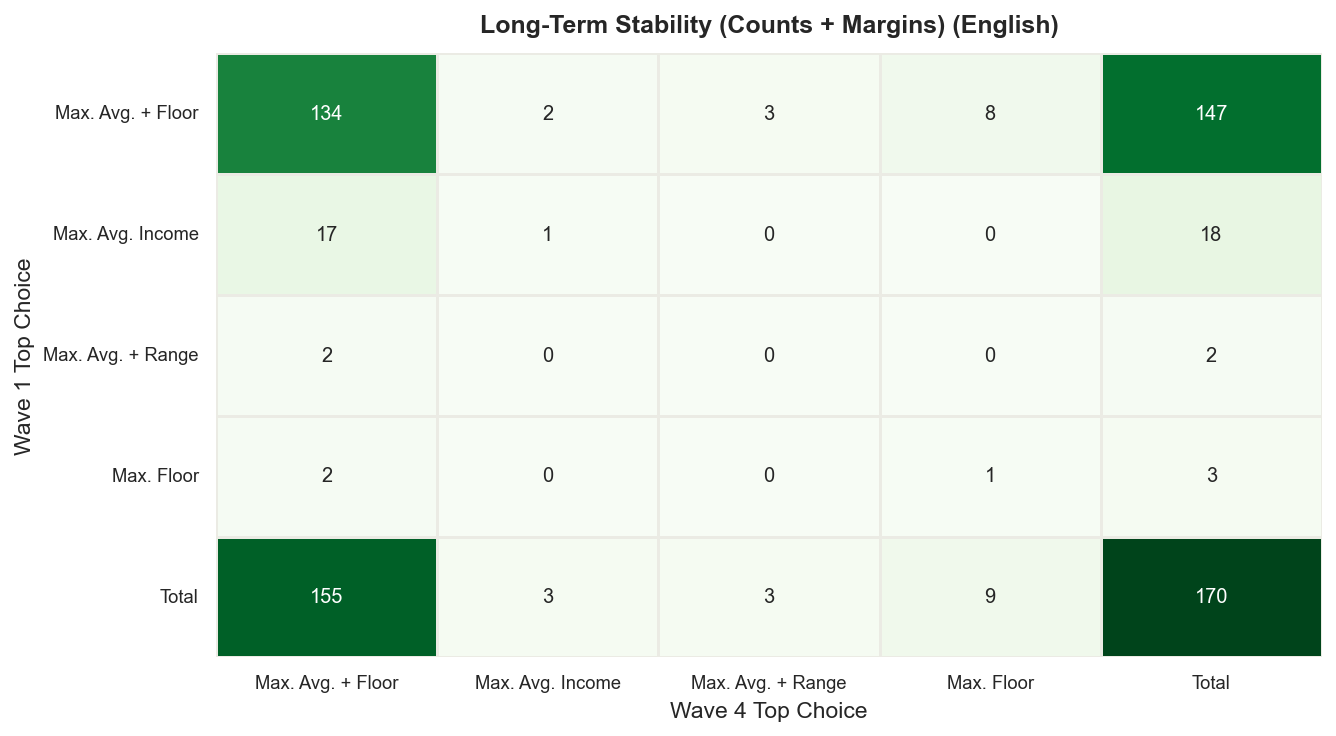

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Maintained Preference Count,Total Agents,Changed Preference %,Maintained Preference %
0,Low,6,10,16,37.5,62.5
1,Medium-Low,10,31,41,24.4,75.6
2,Medium,19,66,85,22.4,77.6
3,Medium-High,3,17,20,15.0,85.0
4,High,1,7,8,12.5,87.5
5,Unknown,0,0,0,0.0,0.0


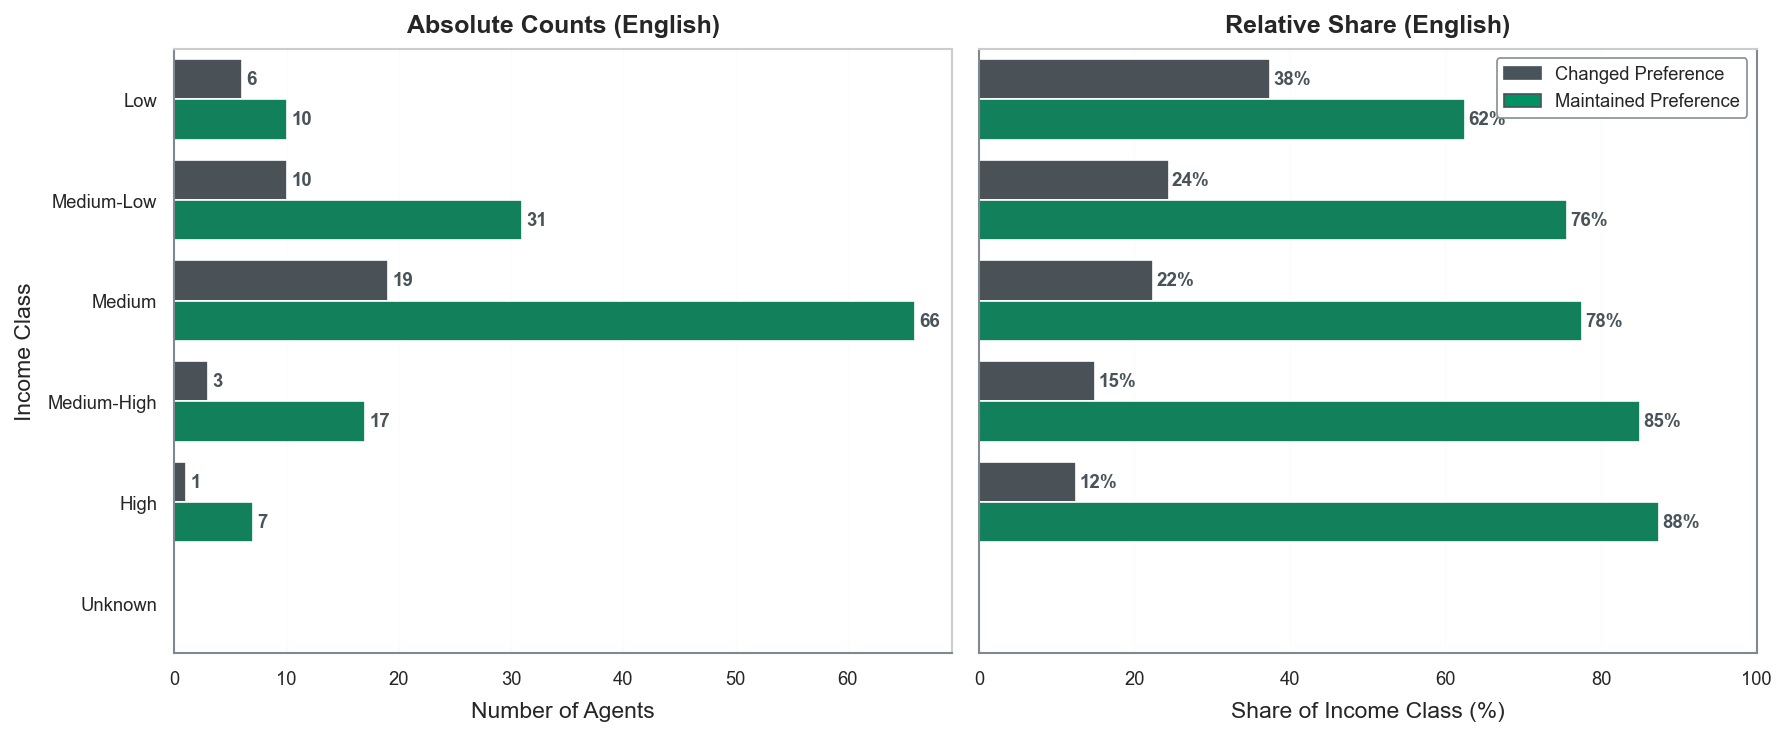

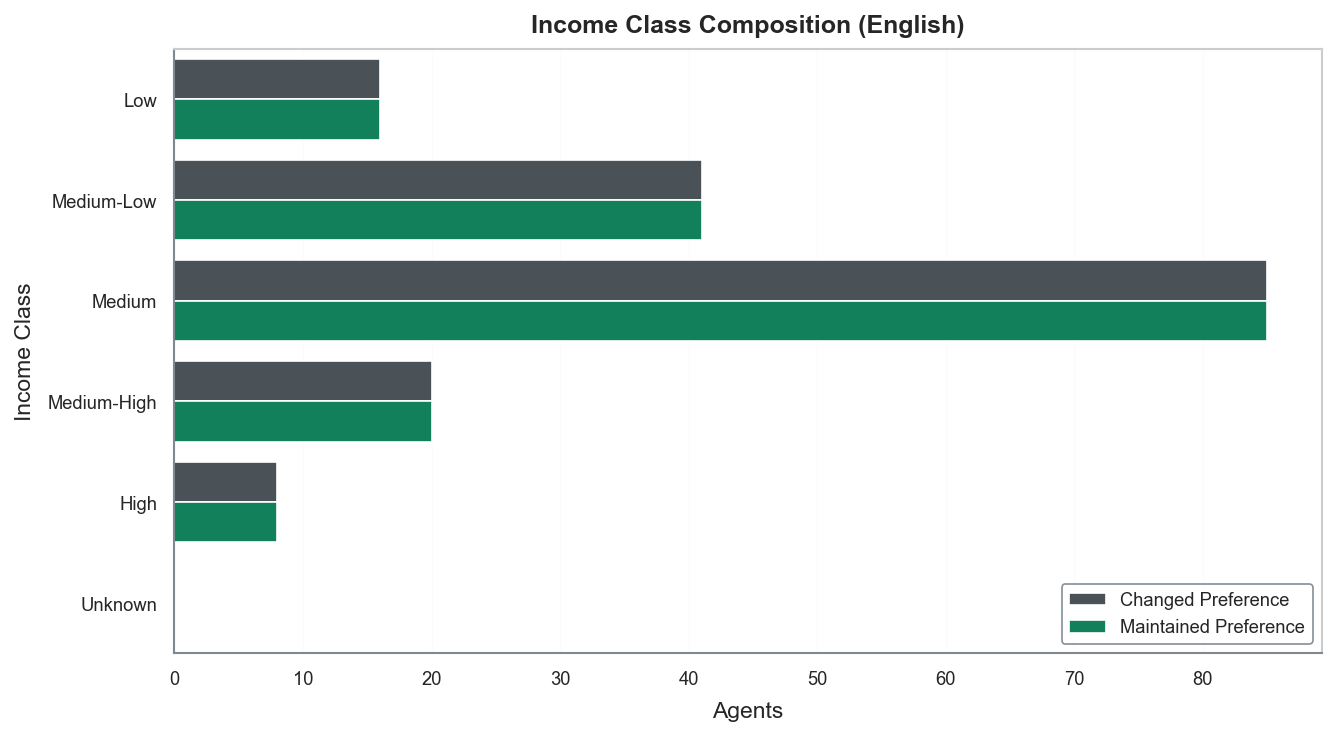

## Spanish Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,19
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,52,30.6
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,32,18.8
2,Max. Avg. + Range > Max. Avg. + Floor > Max. F...,21,12.4
3,Max. Avg. + Range > Max. Floor > Max. Avg. + F...,17,10.0
4,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,12,7.1
5,Max. Avg. + Range > Max. Avg. + Floor > Max. A...,10,5.9
6,Max. Avg. + Range > Max. Avg. Income > Max. Av...,6,3.5
7,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,4,2.4
8,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,3,1.8
9,Max. Avg. + Floor > Max. Avg. Income > Max. Fl...,3,1.8


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,49,28.8
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,39,22.9
2,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,18,10.6
3,Max. Avg. + Range > Max. Avg. + Floor > Max. F...,18,10.6
4,Max. Avg. + Range > Max. Avg. + Floor > Max. A...,12,7.1
5,Max. Floor > Max. Avg. + Floor > Max. Avg. + R...,11,6.5
6,Max. Avg. + Range > Max. Floor > Max. Avg. + F...,7,4.1
7,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,6,3.5
8,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,3,1.8
9,Max. Avg. Income > Max. Avg. + Floor > Max. Fl...,2,1.2


### Rounds to Outcome

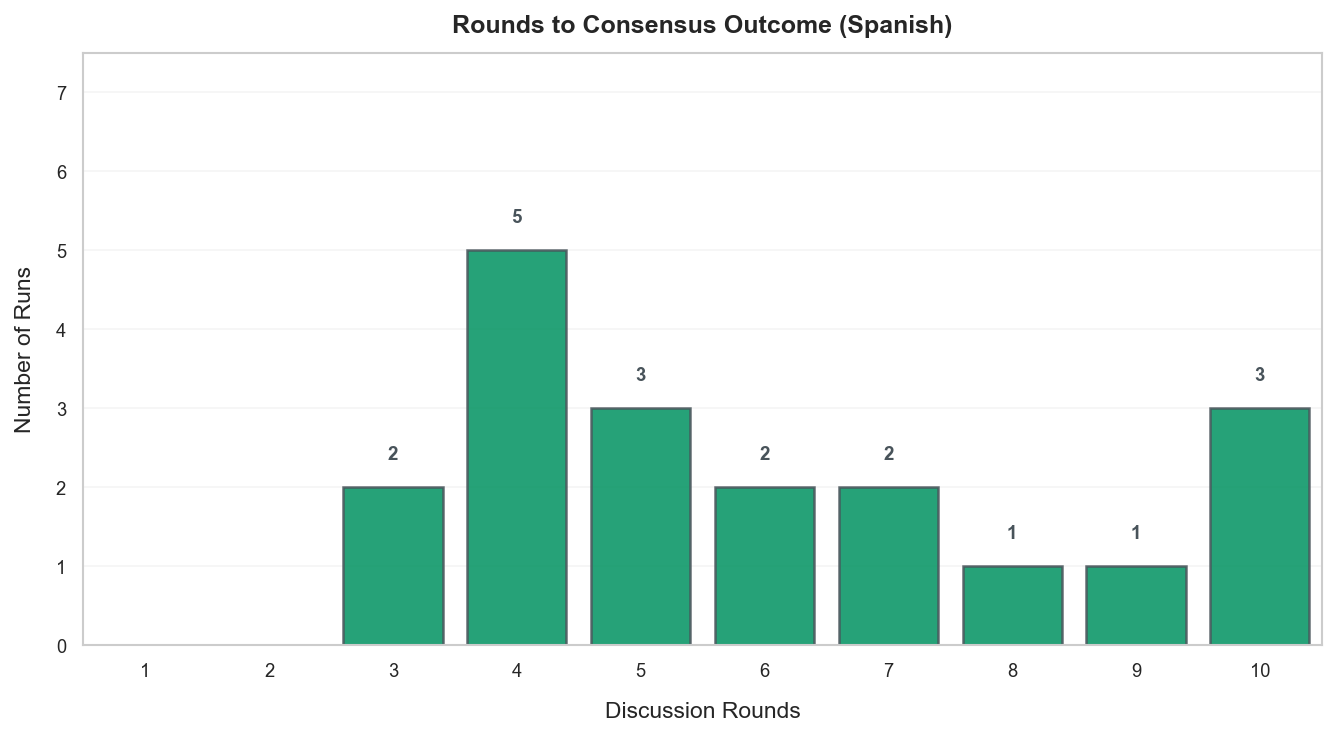

Consensus Timing Summary:
  Total consensus runs: 19
  Range: 3-10 rounds
  Mean: 6.00 rounds  |  Median: 5 rounds


### Floor Constraint Amounts

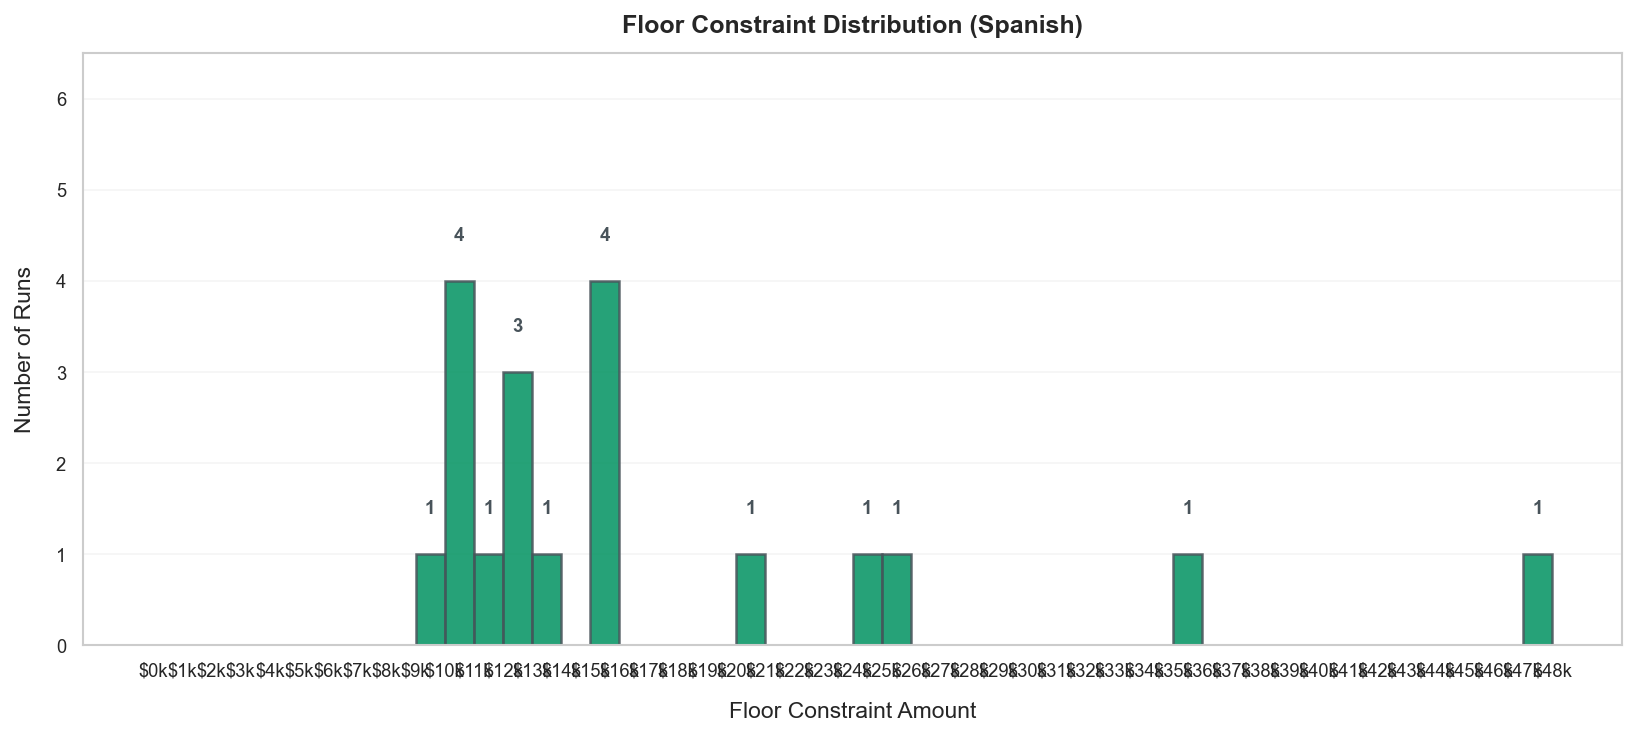

Floor Amount Summary:
  Total votes: 19
  Range: $9,000 - $48,000
  Mean: $16,895  |  Median: $13,000  |  SD: $9,760


### Voting Attempts and Success Rate

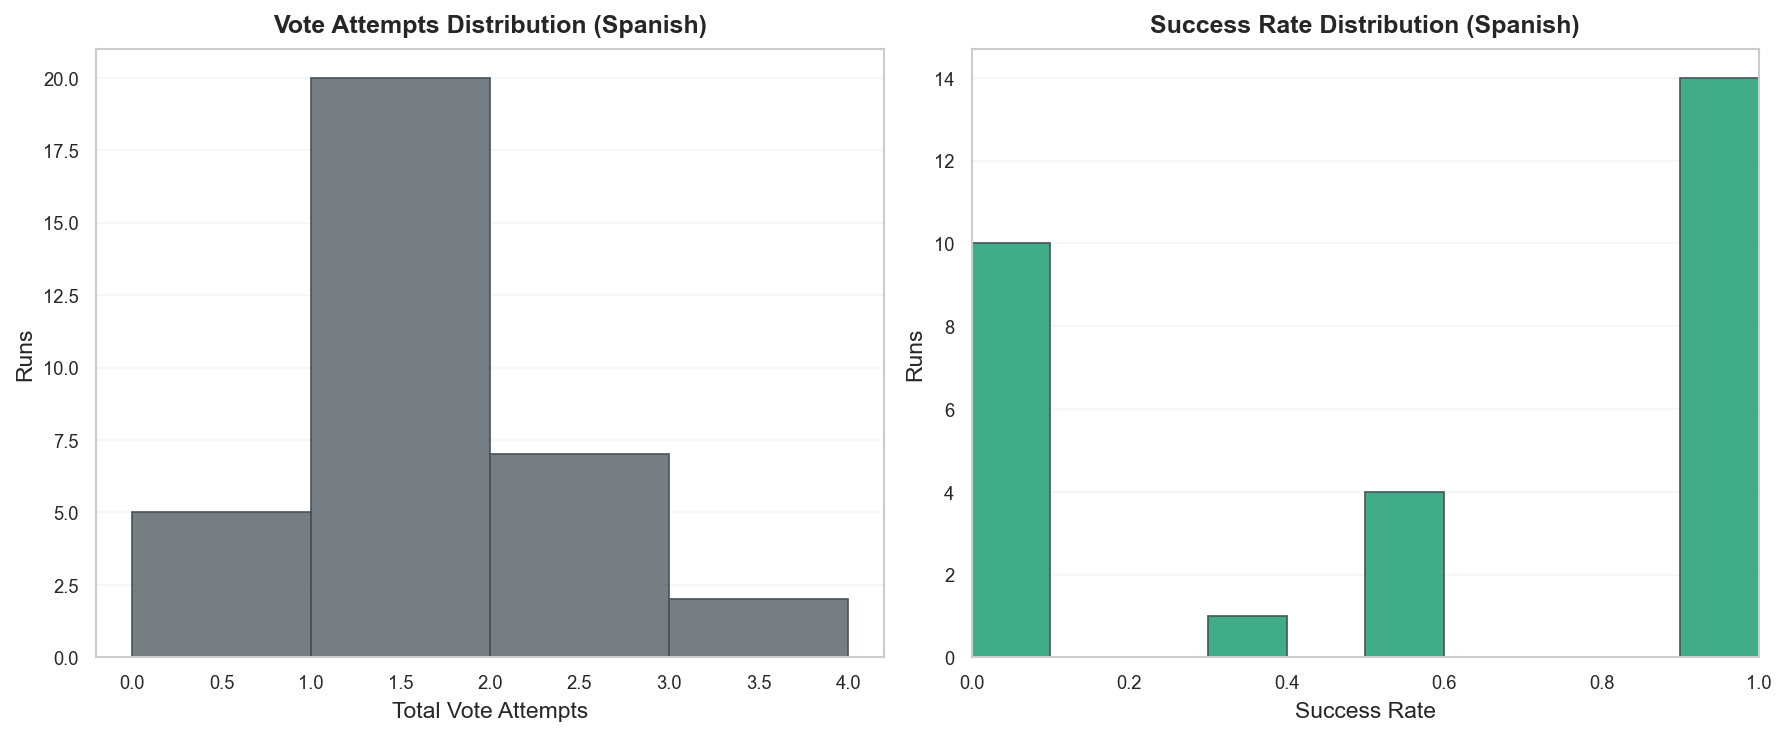

Voting Attempts Summary:
  Mean attempts per run: 1.18
  Median attempts per run: 1
  Mean success rate: 56.32%
  Median success rate: 50.00%


### Preference Evolution and Transitions

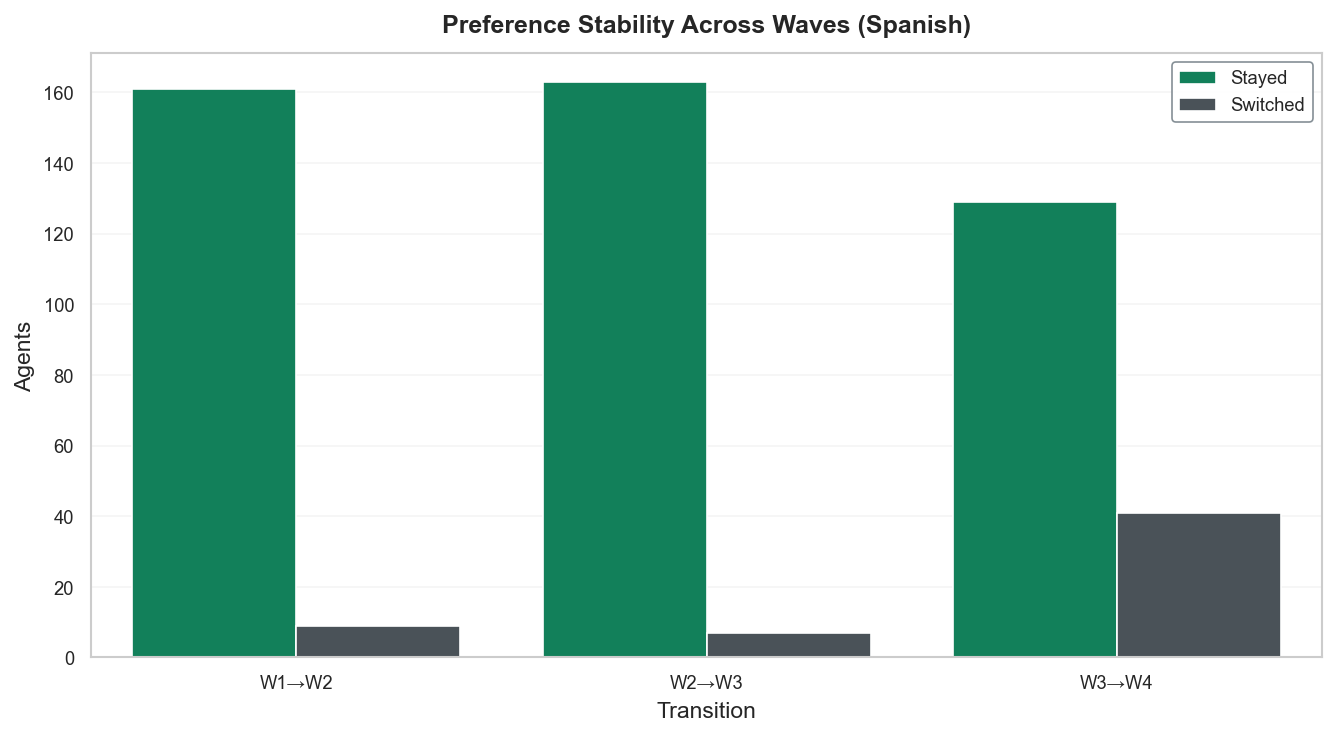

Stability Breakdown:
  W1→W2: 161/170 stayed (94.7%)
  W2→W3: 163/170 stayed (95.9%)
  W3→W4: 129/170 stayed (75.9%)


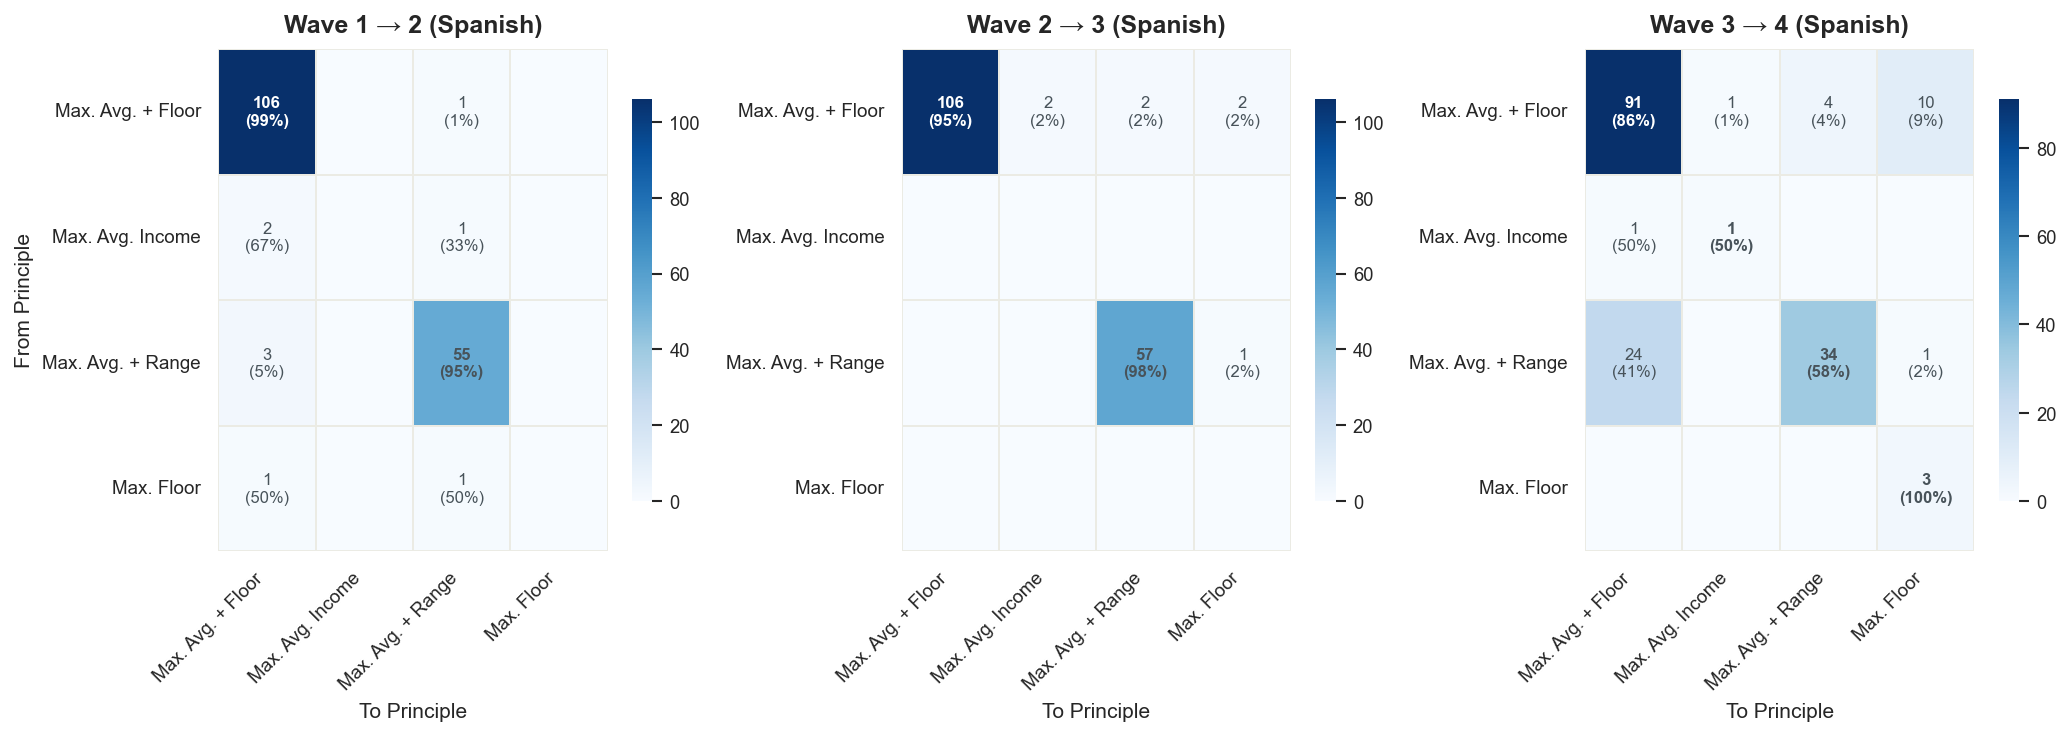

Transition Stay Rates:
  Wave 1 → 2: 161/170 stayed (94.7%)
  Wave 2 → 3: 163/170 stayed (95.9%)
  Wave 3 → 4: 129/170 stayed (75.9%)


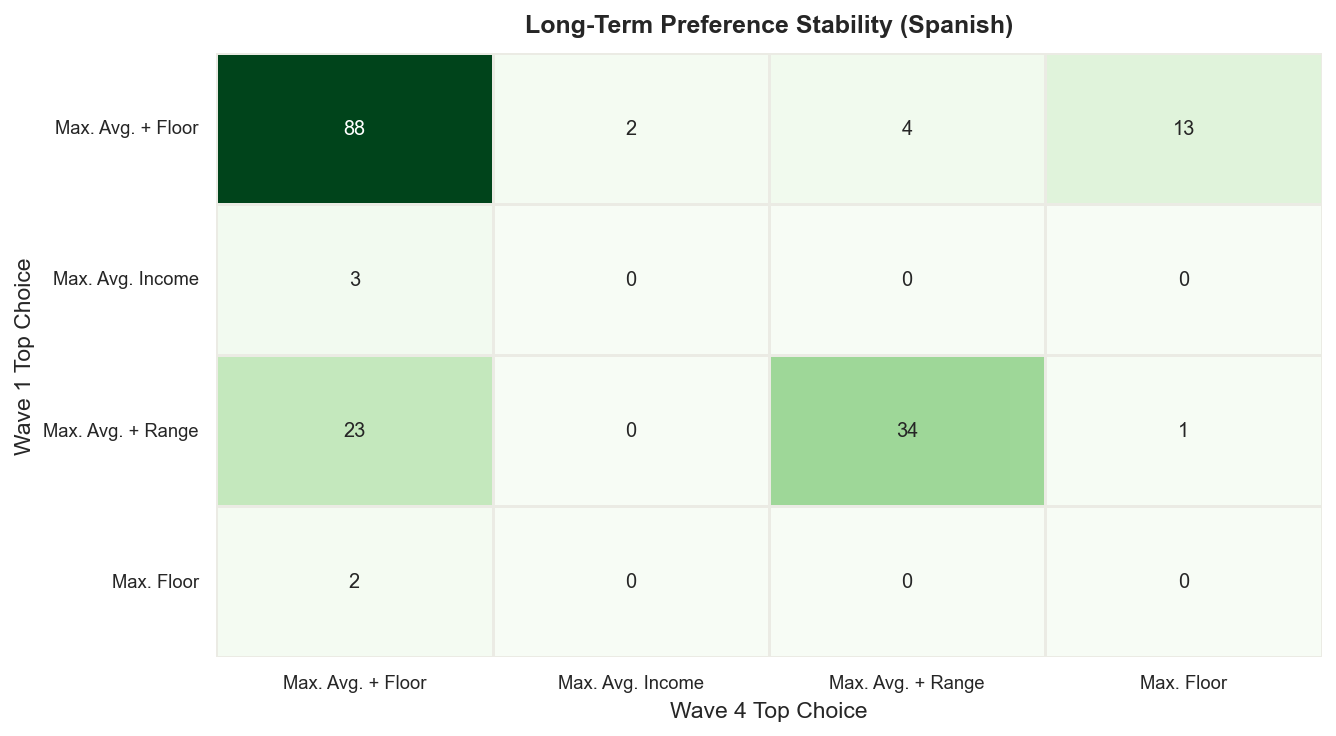

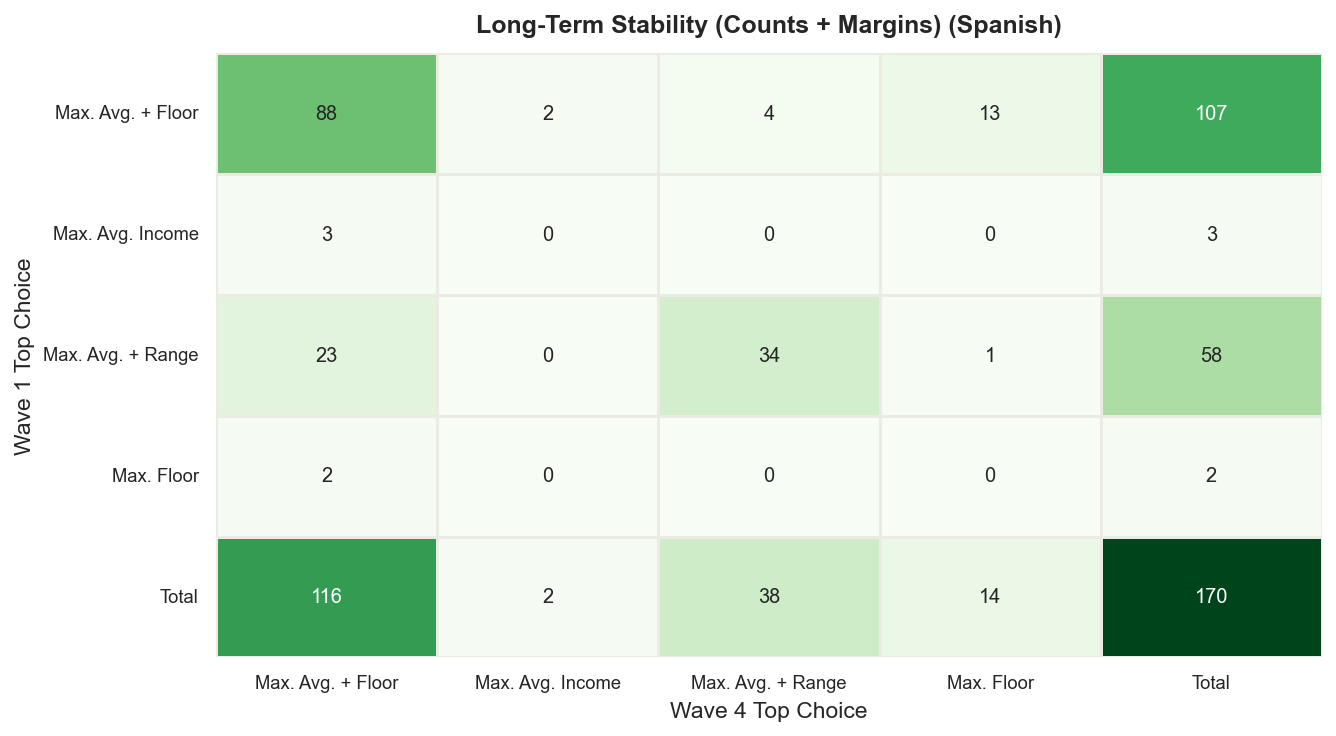

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Maintained Preference Count,Total Agents,Changed Preference %,Maintained Preference %
0,Low,12,8,20,60.0,40.0
1,Medium-Low,12,25,37,32.4,67.6
2,Medium,20,73,93,21.5,78.5
3,Medium-High,6,9,15,40.0,60.0
4,High,1,4,5,20.0,80.0
5,Unknown,0,0,0,0.0,0.0


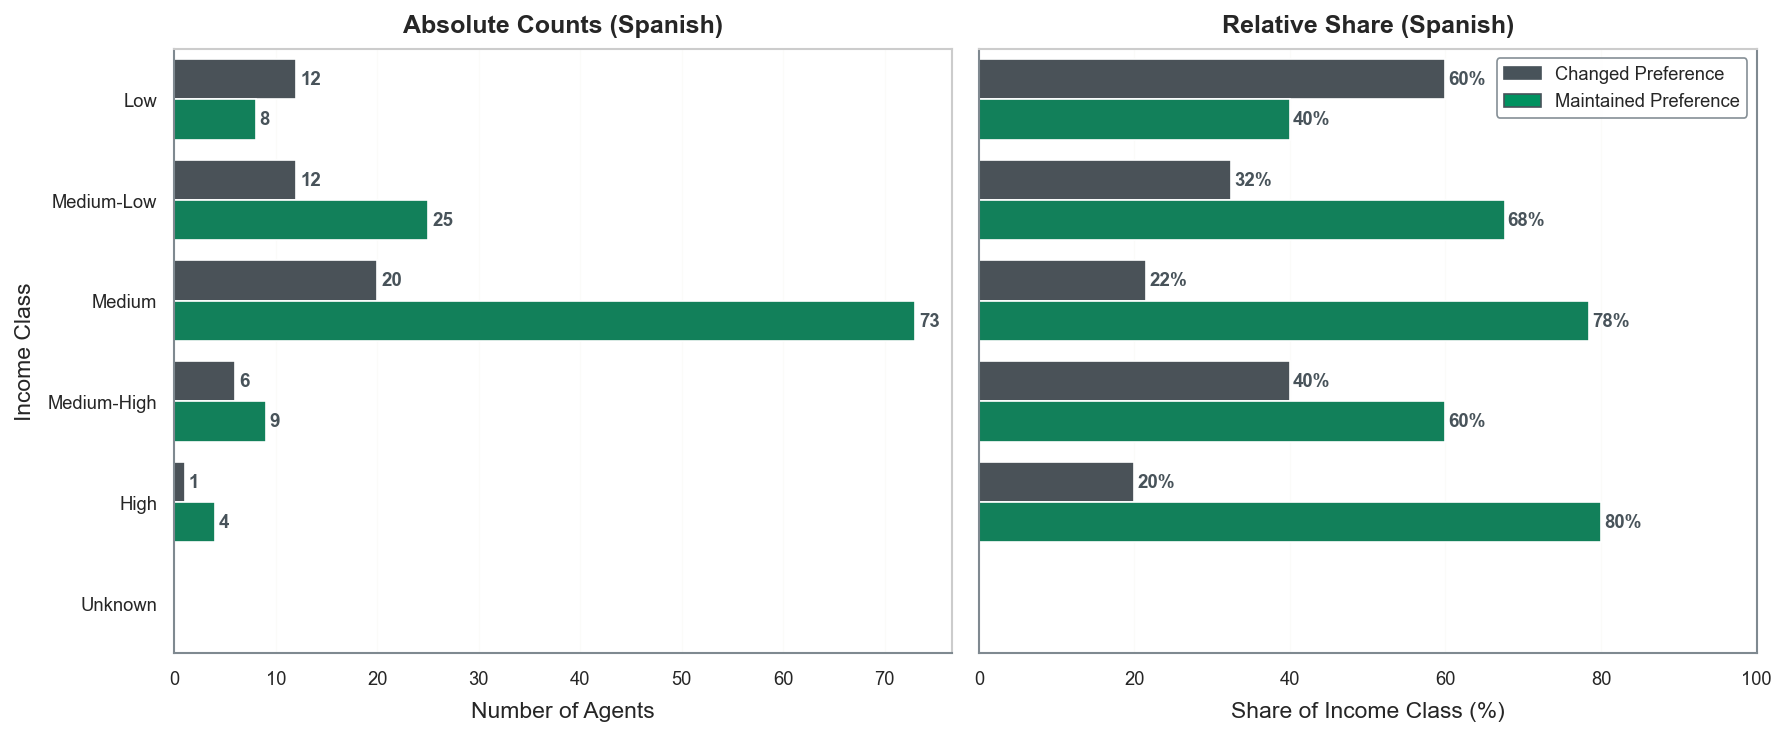

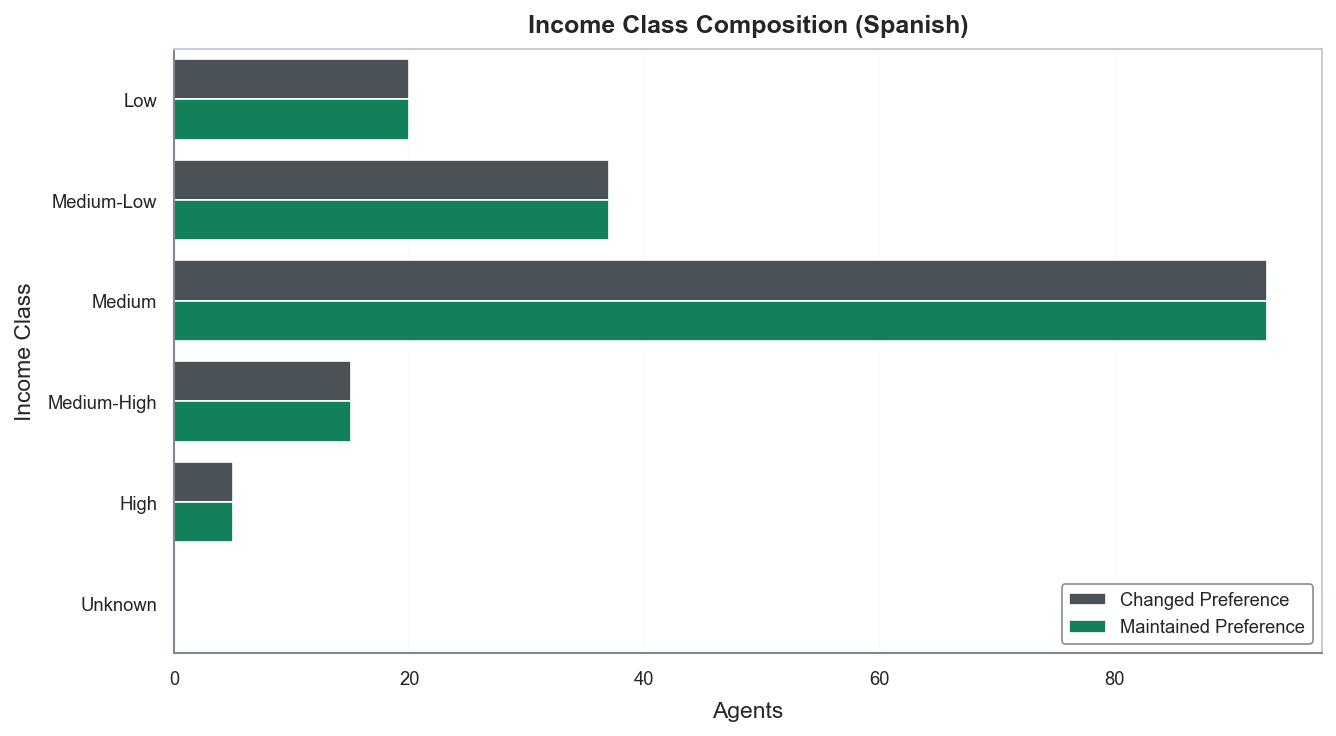

## Mandarin Cohort

### Data Summary

,Metric,Value
0,Runs,34
1,Consensus runs,28
2,Agent sessions,170
3,Preference waves,4


Transition coverage: 170/170 agents with full wave data


### Preference Orderings by Wave

...

**Wave 3 - Final Phase 1**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,42,24.7
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,34,20.0
2,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,29,17.1
3,Max. Floor > Max. Avg. Income > Max. Avg. + Fl...,28,16.5
4,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,10,5.9
5,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,9,5.3
6,Max. Avg. + Floor > Max. Avg. Income > Max. Fl...,8,4.7
7,Max. Floor > Max. Avg. + Floor > Max. Avg. + R...,6,3.5
8,Max. Avg. Income > Max. Avg. + Floor > Max. Av...,3,1.8
9,Max. Avg. + Range > Max. Avg. + Floor > Max. A...,1,0.6


**Wave 4 - Post-Group**

,Preference Ordering,Count,Percentage
0,Max. Avg. + Floor > Max. Floor > Max. Avg. Inc...,49,28.8
1,Max. Avg. + Floor > Max. Avg. + Range > Max. F...,39,22.9
2,Max. Avg. + Floor > Max. Floor > Max. Avg. + R...,22,12.9
3,Max. Avg. + Floor > Max. Avg. Income > Max. Fl...,16,9.4
4,Max. Floor > Max. Avg. + Floor > Max. Avg. + R...,12,7.1
5,Max. Avg. + Floor > Max. Avg. Income > Max. Av...,10,5.9
6,Max. Avg. + Floor > Max. Avg. + Range > Max. A...,9,5.3
7,Max. Floor > Max. Avg. Income > Max. Avg. + Fl...,6,3.5
8,Max. Floor > Max. Avg. + Range > Max. Avg. + F...,2,1.2
9,Max. Avg. + Range > Max. Avg. + Floor > Max. F...,1,0.6


### Rounds to Outcome

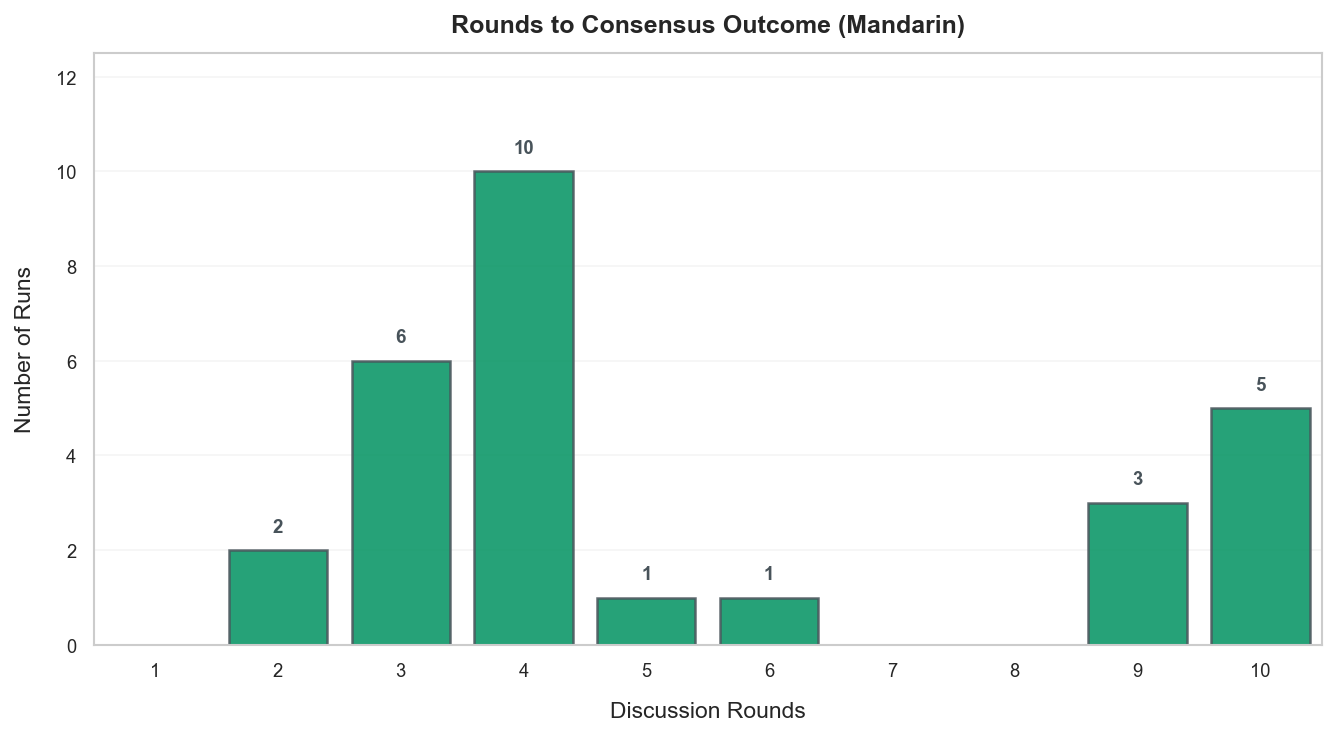

Consensus Timing Summary:
  Total consensus runs: 28
  Range: 2-10 rounds
  Mean: 5.36 rounds  |  Median: 4 rounds


### Floor Constraint Amounts

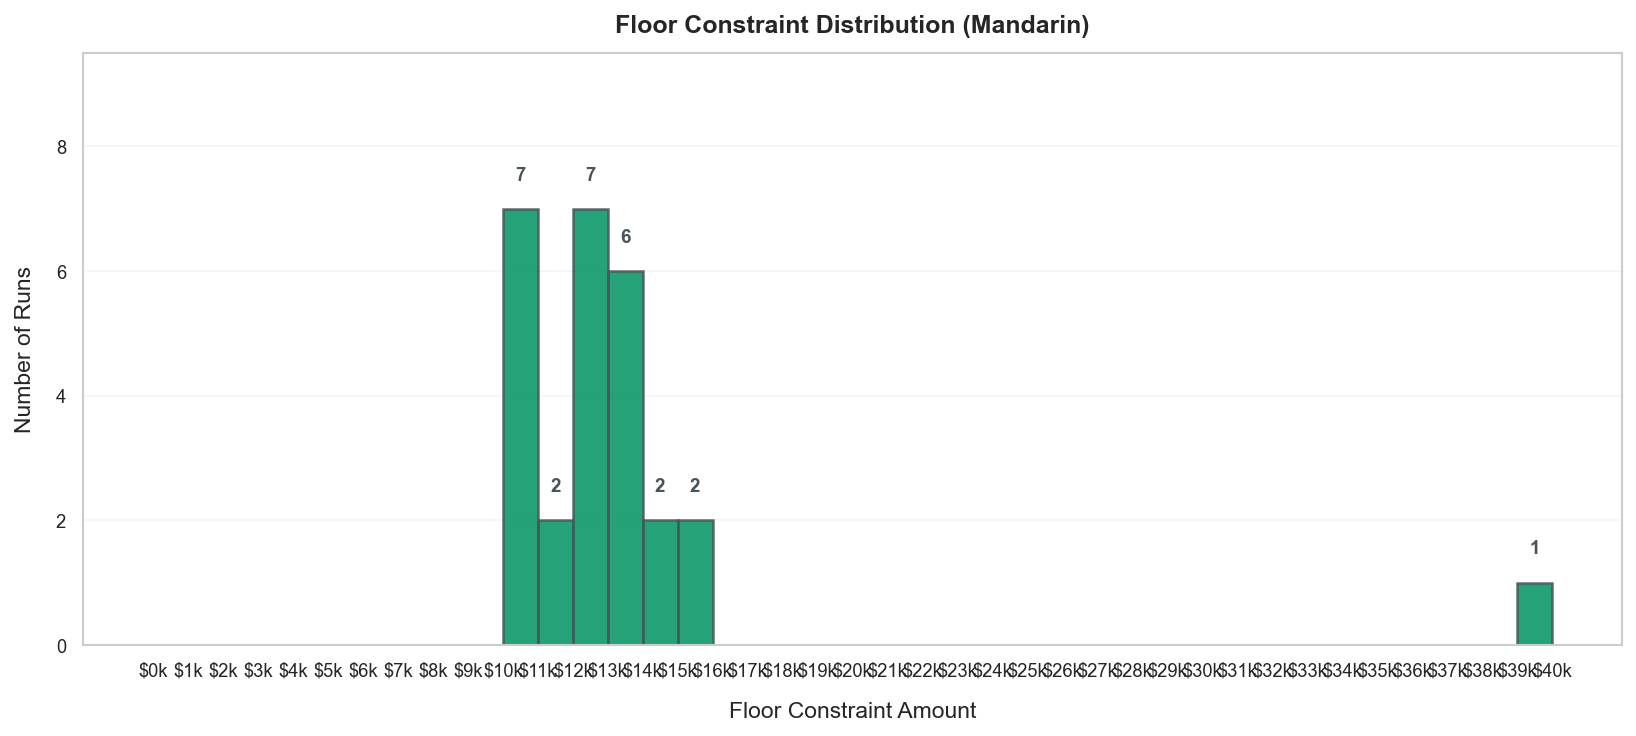

Floor Amount Summary:
  Total votes: 27
  Range: $10,000 - $40,000
  Mean: $13,074  |  Median: $12,000  |  SD: $5,495


### Voting Attempts and Success Rate

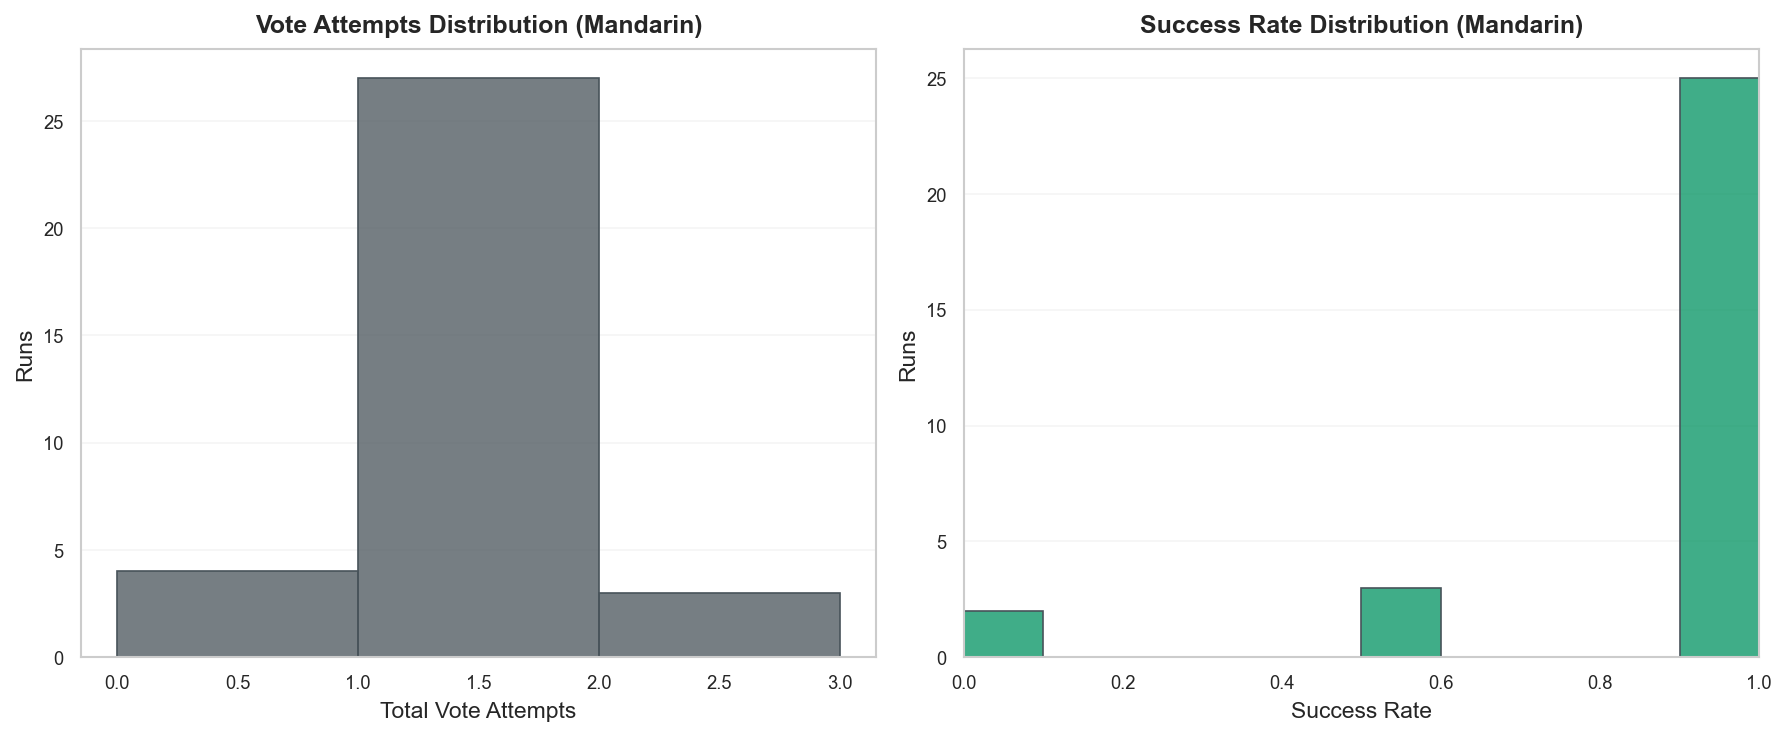

Voting Attempts Summary:
  Mean attempts per run: 0.97
  Median attempts per run: 1
  Mean success rate: 88.33%
  Median success rate: 100.00%


### Preference Evolution and Transitions

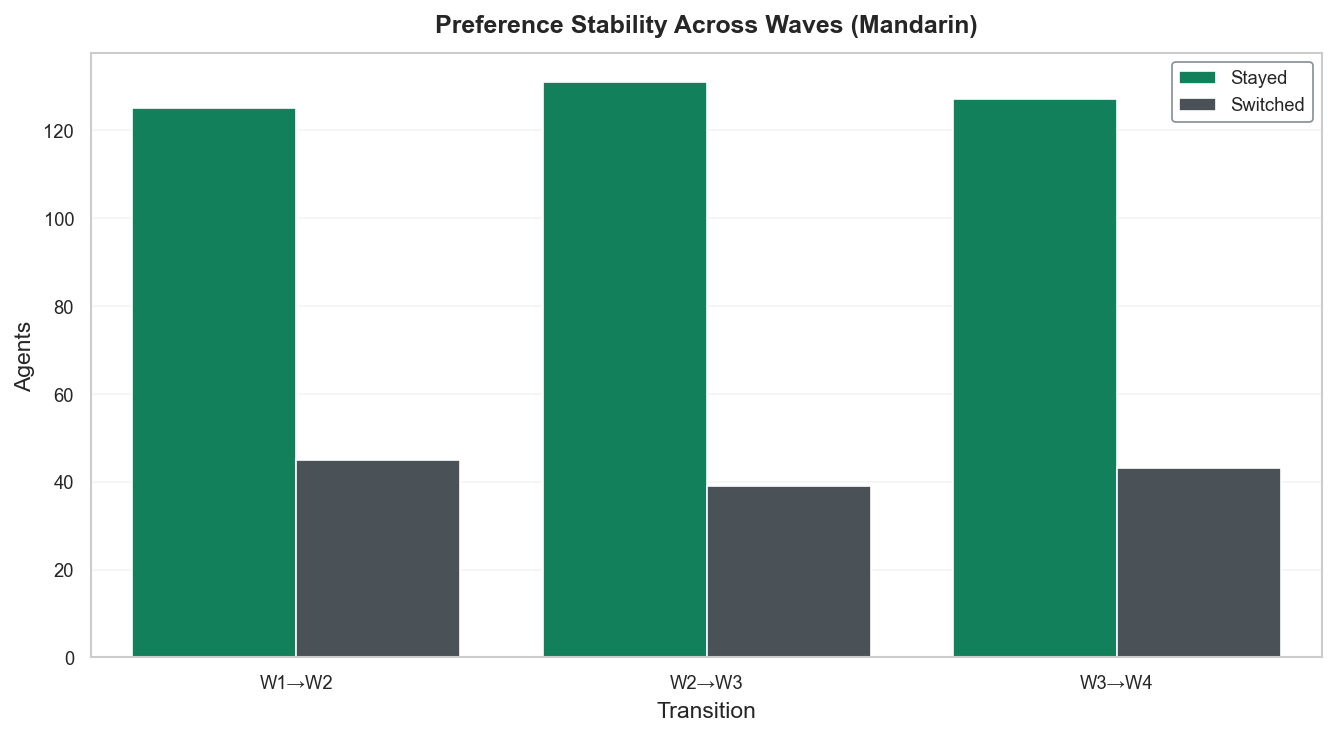

Stability Breakdown:
  W1→W2: 125/170 stayed (73.5%)
  W2→W3: 131/170 stayed (77.1%)
  W3→W4: 127/170 stayed (74.7%)


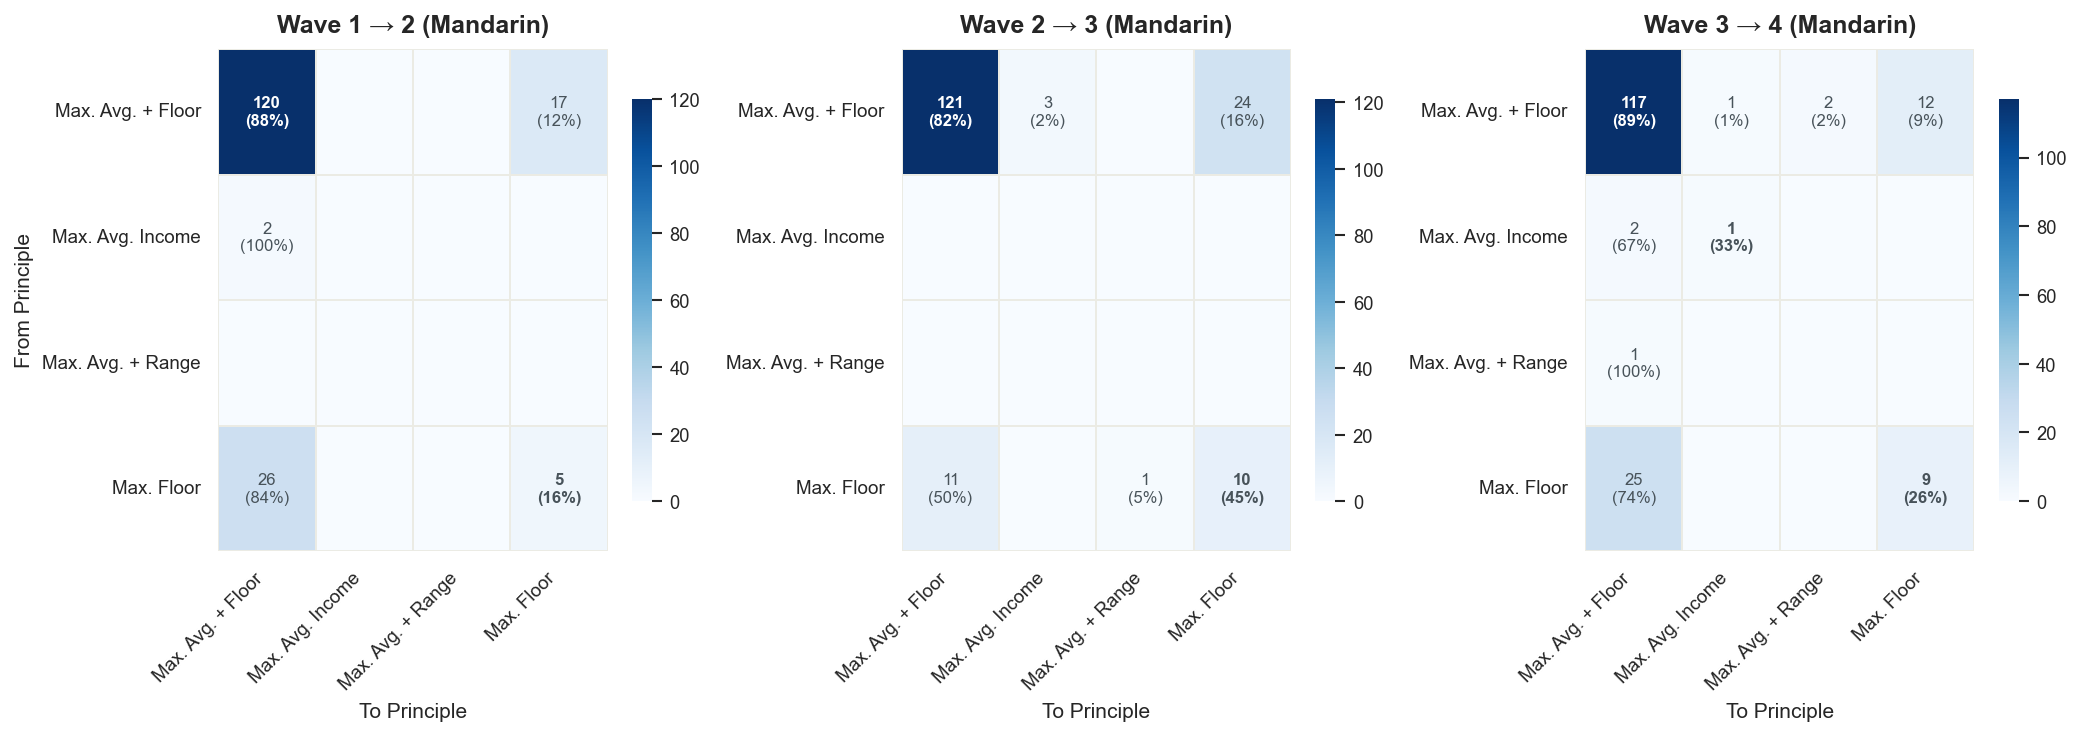

Transition Stay Rates:
  Wave 1 → 2: 125/170 stayed (73.5%)
  Wave 2 → 3: 131/170 stayed (77.1%)
  Wave 3 → 4: 127/170 stayed (74.7%)


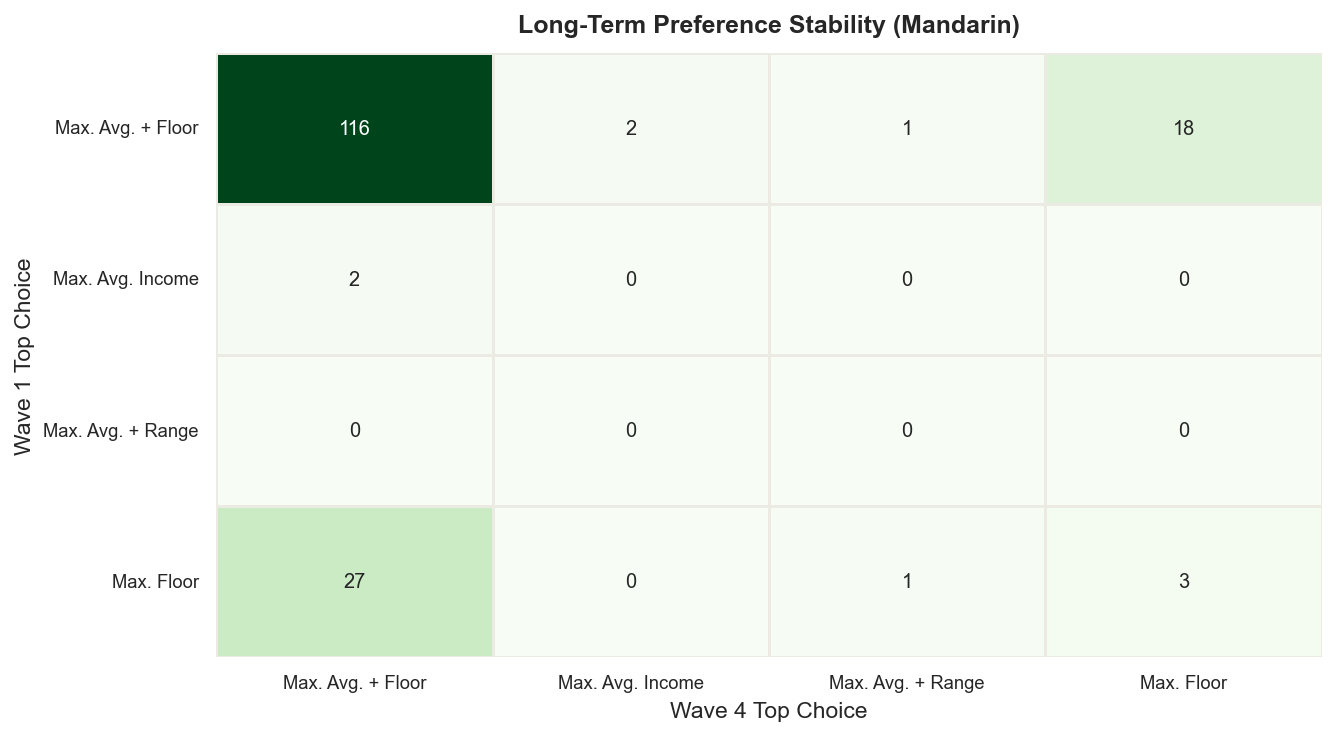

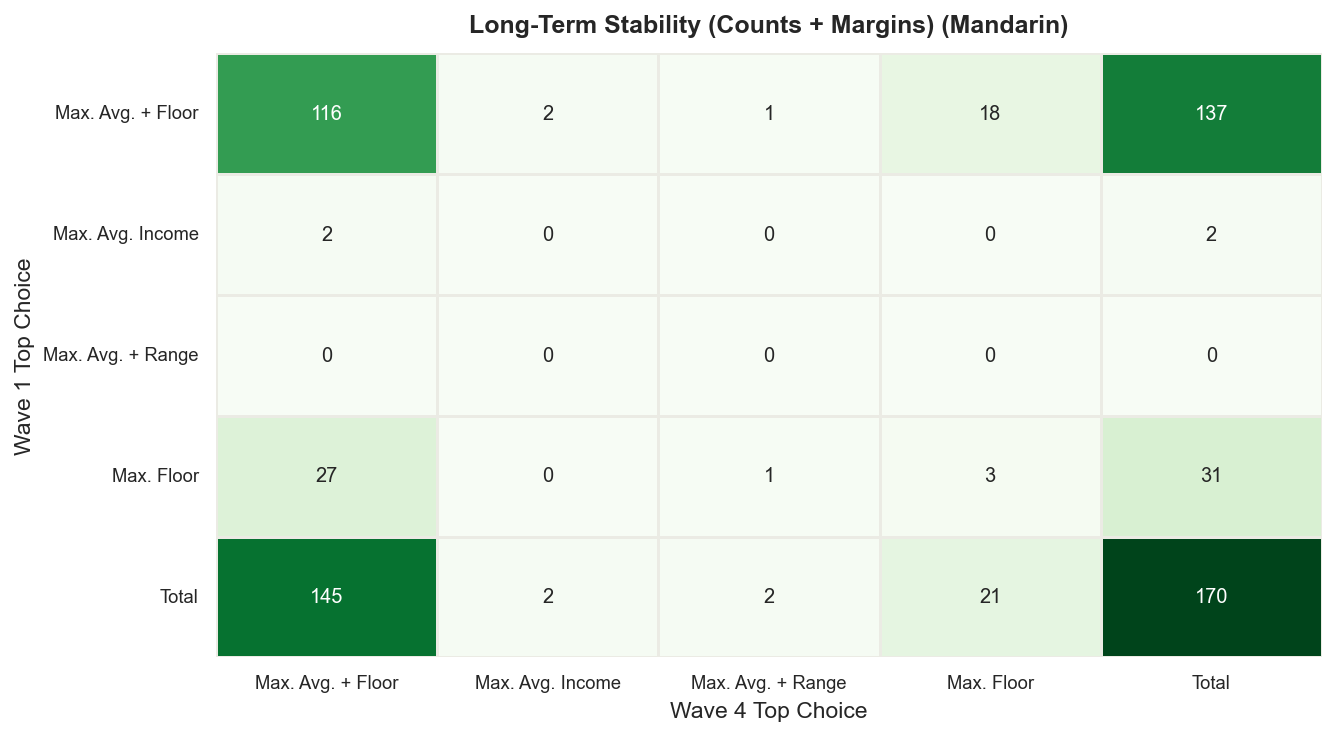

### Switcher Analysis: Income Class and Preference Changes

,Income Class,Changed Preference Count,Maintained Preference Count,Total Agents,Changed Preference %,Maintained Preference %
0,Low,10,11,21,47.6,52.4
1,Medium-Low,25,16,41,61.0,39.0
2,Medium,37,48,85,43.5,56.5
3,Medium-High,7,8,15,46.7,53.3
4,High,5,3,8,62.5,37.5
5,Unknown,0,0,0,0.0,0.0


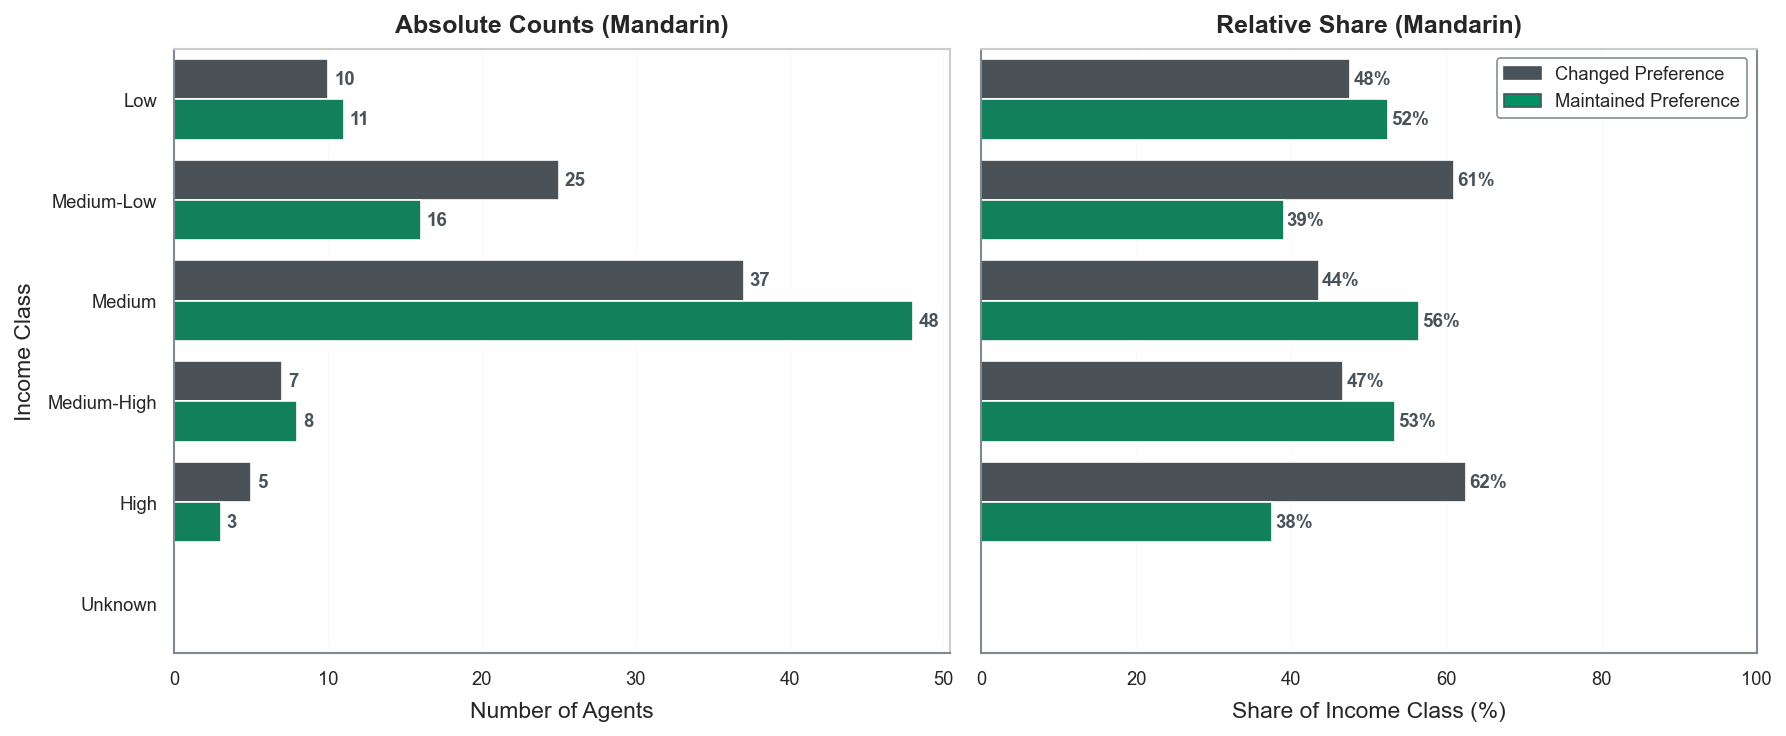

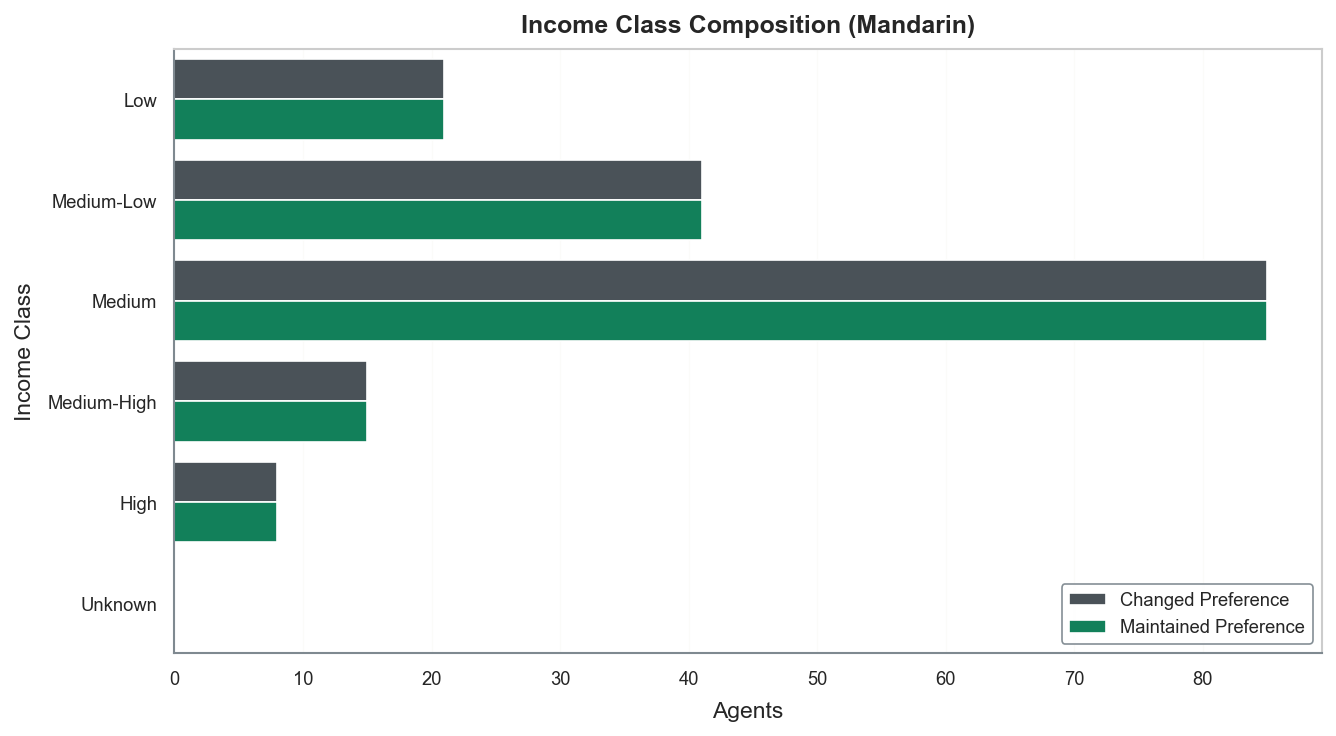

In [ ]:

# Run full descriptive workflow per cohort

for label, dataset in group_datasets.items():
    display(Markdown(f"## {label} Cohort"))

    # Data summary
    display(Markdown("### Data Summary"))
    num_runs = dataset.run_metrics.shape[0]
    consensus_runs = dataset.run_metrics[dataset.run_metrics["consensus_reached"] == True].shape[0]
    unique_agents = dataset.ranking_top[["run_id", "agent"]].drop_duplicates().shape[0]
    num_waves = dataset.ranking_top["wave_label"].nunique()
    summary_df = pd.DataFrame(
        {
            "Metric": ["Runs", "Consensus runs", "Agent sessions", "Preference waves"],
            "Value": [num_runs, consensus_runs, unique_agents, num_waves],
        }
    )
    display(summary_df)
    if dataset.transition_meta:
        total = dataset.transition_meta.get("total_agents", 0)
        complete = dataset.transition_meta.get("complete_cases", 0)
        print(f"Transition coverage: {complete}/{total} agents with full wave data")

    # Preference orderings
    display(Markdown("### Preference Orderings by Wave"))
    for wave_name in WAVE_ORDER:
        display(Markdown(f"**{wave_name}**"))
        table = create_preference_ordering_table(dataset.ranking_long, wave_name)
        display(table)

    # Rounds to outcome
    display(Markdown("### Rounds to Outcome"))
    plot_rounds_to_outcome(dataset.run_metrics, label)

    # Floor constraints
    display(Markdown("### Floor Constraint Amounts"))
    plot_floor_constraint_distribution(dataset.vote_rounds, label)

    # Voting attempts
    display(Markdown("### Voting Attempts and Success Rate"))
    plot_voting_attempts_summary(dataset.run_metrics, label)

    # Preference transitions
    display(Markdown("### Preference Evolution and Transitions"))
    plot_preference_stability(dataset.transition_data, label)
    plot_transition_heatmaps(dataset.transition_data, label)
    plot_long_term_stability(dataset.transition_data, label)
    plot_long_term_margin(dataset.transition_data, label)

    # Switcher analysis
    display(Markdown("### Switcher Analysis: Income Class and Preference Changes"))
    if dataset.switcher_analysis is None or dataset.switcher_analysis.empty:
        print("No switcher data available for this cohort.")
    else:
        switcher_summary, count_long, percent_long, composition_percent_long = summarize_income_preferences(dataset.switcher_analysis)
        display(switcher_summary)
        plot_income_preference_bars(switcher_summary, count_long, percent_long, label)
        plot_income_composition(count_long, composition_percent_long, label)


In [ ]:

# Cross-cohort comparison of final top choices

final_choice_records: List[Dict[str, Any]] = []
for label, dataset in group_datasets.items():
    if dataset.transition_data is None or dataset.transition_data.empty:
        continue
    final_wave = dataset.transition_data["wave4"].map(format_principle_label)
    counts = final_wave.value_counts()
    total = counts.sum()
    for principle, count in counts.items():
        final_choice_records.append({
            "Cohort": label,
            "Top Principle": principle,
            "Agents": int(count),
            "Share %": round(count / total * 100, 1) if total else np.nan,
        })

final_choice_df = pd.DataFrame(final_choice_records).sort_values(["Top Principle", "Cohort"])

display(Markdown("### Final Wave Top-Choice Distribution"))
display(final_choice_df)


### Final Wave Top-Choice Distribution

,Cohort,Top Principle,Agents,Share %
0,English,Max. Avg. + Floor,155,91.2
8,Mandarin,Max. Avg. + Floor,145,85.3
4,Spanish,Max. Avg. + Floor,116,68.2
2,English,Max. Avg. + Range,3,1.8
10,Mandarin,Max. Avg. + Range,2,1.2
5,Spanish,Max. Avg. + Range,38,22.4
3,English,Max. Avg. Income,3,1.8
11,Mandarin,Max. Avg. Income,2,1.2
7,Spanish,Max. Avg. Income,2,1.2
1,English,Max. Floor,9,5.3
